# Этап EDA

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/kaggle/input/dataset-titanic/Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Описание колонок:
* PassengerId - уникальный идентификатор пассажира
* Survived - факт выживания (0 - не выжил, 1 - выжил) пассажира
* Pclass - класс билета (1 - высший, 2 - средний, 3 - низший)
* Name - полное имя пассажира
* Sex - пол пассажира
* Age - возраст пассажира
* SibSp - количество братьев/сестер или супругов пассажира на борту
* Parch - количество детей/родителей пассажира на борту
* Ticket - билет пассажира
* Fare - стоимость билета
* Cabin - номер каюты
* Embarked - порт посадки (С - Шербург, Q - Куинстаун, S - Саутгемптон)

In [2]:
#Общая информация
print('Размеры датасета:')
print(df.shape)
print("\nТипы данных:")
print(df.dtypes)
print("\nПропуски:")
print(df.isnull().sum())

total_df = df.groupby('Survived',as_index=False).agg({'PassengerId':'count'}).rename(columns={'PassengerId':'SurvivorsNumber'})
total_df['TotalNumber'] = len(df)
total_df['Percent'] = round((total_df['SurvivorsNumber'] / total_df['TotalNumber'] * 100), 2)
print('\nОбщее количество выживших и погибших:')
print(total_df)

Размеры датасета:
(891, 12)

Типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Пропуски:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Общее количество выживших и погибших:
   Survived  SurvivorsNumber  TotalNumber  Percent
0         0              549          891    61.62
1         1              342          891    38.38


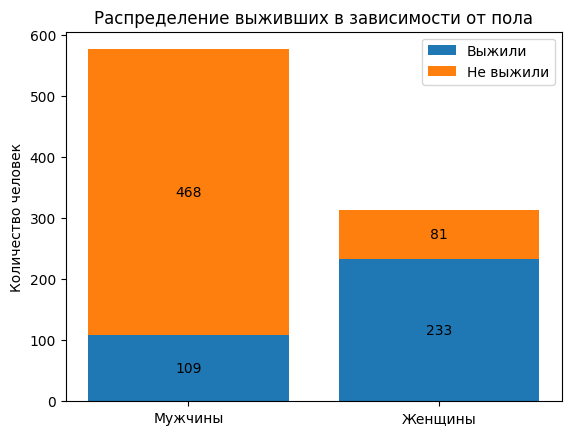

Процентное соотношение выживших:
Мужчины: 18.89%
Женщины: 74.2%


In [ ]:
#Рассмотрим количество выживших и погибших среди женщин и мужчин
#Предполагается, что количество выживших среди женщин больше, чем среди мужчин, потому что женщины имели приоритет при спасении

# ============================================================
# АНАЛИЗ ВЫЖИВАЕМОСТИ В ЗАВИСИМОСТИ ОТ ПОЛА ПАССАЖИРОВ
# ============================================================

# ----- 1. Подсчет общего количества мужчин и женщин -----
# Создаем булевы маски для фильтрации строк по полу
# df.loc[условие] - выбирает строки, где условие истинно
# len() - считает количество выбранных строк
males_total = len(df.loc[df['Sex'] == 'male'])        # Всего мужчин на борту
females_total = len(df.loc[df['Sex'] == 'female'])    # Всего женщин на борту

# ----- 2. Подсчет выживших мужчин и женщин -----
# Используем составное условие с оператором & (логическое "И")
# Выбираем строки, где пол = мужской И выживание = 1 (выжил)
males_survived = len(df.loc[(df['Sex'] == 'male') & (df['Survived'] == 1)])
# Выбираем строки, где пол = женский И выживание = 1 (выжила)
females_survived = len(df.loc[(df['Sex'] == 'female') & (df['Survived'] == 1)])

# ----- 3. Подготовка данных для визуализации (столбчатой диаграммы) -----
# Создаем словарь, где ключи - категории (Выжили/Не выжили),
# а значения - списки с данными для мужчин и женщин
survivors_counts = {
    'Выжили': [males_survived, females_survived],     # Выжившие (муж, жен)
    'Не выжили': [males_total - males_survived,       # Погибшие (муж, жен)
                  females_total - females_survived]    # = всего - выжившие
}

# ----- 4. Построение столбчатой диаграммы с накоплением -----
fig, ax = plt.subplots()                      # Создаем фигуру и оси для графика
bottom = np.zeros(2)                           # Начальные позиции для нижней части столбцов

# Цикл по категориям: сначала 'Выжили', потом 'Не выжили'
for name, value in survivors_counts.items():
    # Рисуем столбцы для текущей категории
    # ('Мужчины', 'Женщины') - подписи по оси X
    # value - высота текущего сегмента для каждой группы
    # label=name - подпись для легенды
    # bottom=bottom - с какого уровня начинать рисовать сегмент
    column = ax.bar(('Мужчины', 'Женщины'), value, label=name, bottom=bottom)
    
    # Увеличиваем bottom на высоту текущего сегмента для следующей категории
    bottom += value
    
    # Добавляем числовые подписи в центр каждого сегмента
    ax.bar_label(column, label_type='center')

# ----- 5. Оформление и отображение графика -----
ax.set_title('Распределение выживших в зависимости от пола')  # Заголовок
ax.set_ylabel('Количество человек')                            # Подпись оси Y
ax.legend()                                                    # Отображаем легенду
plt.show()                                                      # Показываем график

# ----- 6. Расчет и вывод процентного соотношения -----
# Формула процента: (часть / целое) * 100
percentage_males_survived = (males_survived / males_total) * 100    # % выживших мужчин
percentage_females_survived = (females_survived / females_total) * 100  # % выживших женщин

print('Процентное соотношение выживших:')
print(f"Мужчины: {round(percentage_males_survived, 2)}%")   # Округляем до 2 знаков
print(f"Женщины: {round(percentage_females_survived, 2)}%")
print(f"Женщины: {round(percentage_females_survived, 2)}%")

**Вывод: гипотеза подтвердилась - женщины имели значительно более высокие шансы на выживание, что объясняется известным принципом "сначала женщины и дети" при эвакуации с Титаника, при этом разница в выживаемости по полу составляет более 55 процентов, что делает пол одним из самых важных факторов выживания.**

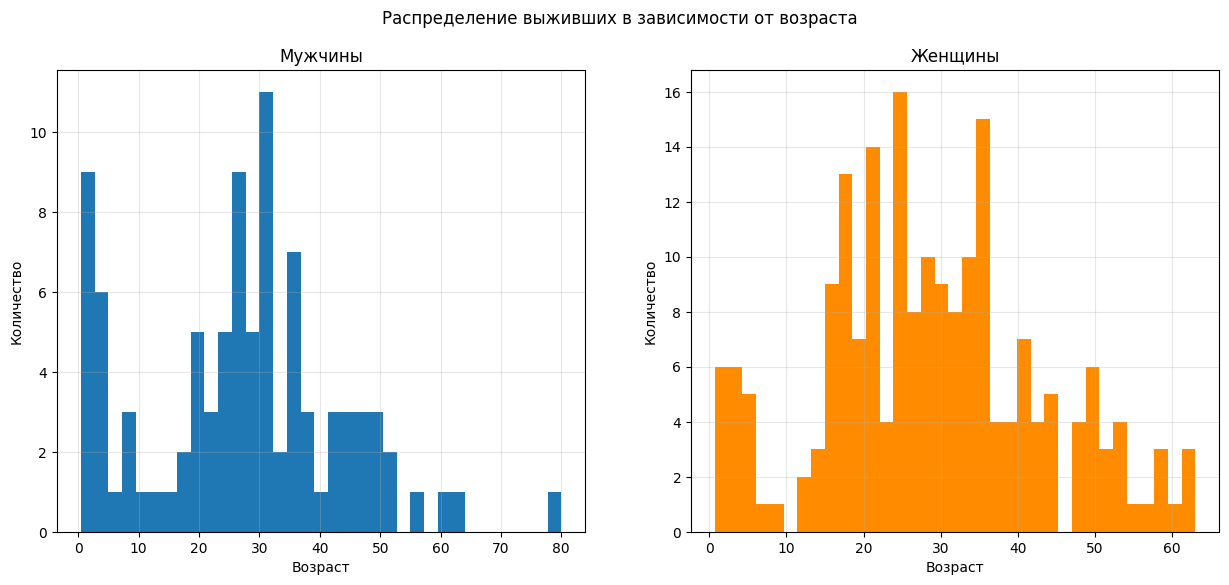

Среди детей выжило 89.47%


In [ ]:
# ============================================================
# АНАЛИЗ ВЫЖИВАЕМОСТИ В ЗАВИСИМОСТИ ОТ ВОЗРАСТА И ПОЛА
# ============================================================

# ----- 1. Извлечение возрастов выживших пассажиров по полу -----
# Выбираем строки, где пол = мужской И выживание = 1, затем берем колонку 'Age'
# dropna() удаляет пропущенные значения (NaN), чтобы они не мешали построению гистограммы
males_survived = df.loc[(df['Sex'] == 'male') & (df['Survived'] == 1)]['Age'].dropna()

# Аналогично для женщин: выбираем выживших женщин и извлекаем их возраст
females_survived = df.loc[(df['Sex'] == 'female') & (df['Survived'] == 1)]['Age'].dropna()

# ----- 2. Создание полотна для двух гистограмм рядом -----
# plt.subplots(1, 2) создает 1 строку и 2 колонки графиков
# figsize=(15, 6) задает размер всего полотна (ширина 15, высота 6)
# ax1 и ax2 - это отдельные объекты для управления левым и правым графиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Добавляем общий заголовок для всей фигуры (над обоими графиками)
fig.suptitle('Распределение выживших в зависимости от возраста')

# ----- 3. Построение гистограммы для мужчин (левый график) -----
# hist() строит гистограмму распределения возрастов
# bins=35 - количество корзин (столбцов) гистограммы
ax1.hist(males_survived, bins=35)
ax1.set_title('Мужчины')                          # Заголовок для левого графика
ax1.set_xlabel('Возраст')                          # Подпись оси X
ax1.set_ylabel('Количество')                       # Подпись оси Y
ax1.grid(alpha=0.3)                                 # Добавляем сетку с прозрачностью 30%

# ----- 4. Построение гистограммы для женщин (правый график) -----
# color='darkorange' задает оранжевый цвет столбцов для отличия от мужчин
ax2.hist(females_survived, bins=35, color='darkorange')
ax2.set_title('Женщины')                           # Заголовок для правого графика
ax2.set_xlabel('Возраст')
ax2.set_ylabel('Количество')
ax2.grid(alpha=0.3)

# Отображаем оба графика
plt.show()

# ----- 5. Анализ выживаемости среди детей -----
# Создаем копию датафрейма с удаленными пропусками (особенно в колонке Age)
# dropna() без параметров удаляет ЛЮБЫЕ строки, где есть хотя бы один пропуск
children_df = df.dropna()

# Подсчет общего количества детей (возраст < 18 лет)
# np.float64(18.0) преобразует 18 в тот же тип данных, что и колонка Age (float64)
# Это нужно для корректного сравнения
children_total = len(children_df.loc[children_df['Age'] < np.float64(18.0)])

# Подсчет выживших детей (возраст < 18 И выживание = 1)
children_survived = len(children_df.loc[
    (children_df['Age'] < np.float64(18.0)) &    # Условие 1: ребенок
    (children_df['Survived'] == 1)                # Условие 2: выжил
])

# Расчет процента выживших детей: (выжившие дети / все дети) * 100
# round(..., 2) округляет результат до 2 знаков после запятой
percentages_children_survived = round(children_survived / children_total * 100, 2)

# Вывод результата
print(f'Среди детей выжило {percentages_children_survived}%')

**Вывод: гипотеза подтвердилась - дети действительно имели очень высокие шансы на выживание, при этом среди выживших мужчин преобладают молодые люди 20-35 лет, а среди женщин наблюдается два пика: молодые женщины и девочки-подростки, что дополнительно подтверждает принцип "сначала женщины и дети", особенно заметный в почти полном отсутствии выживших мужчин старше 50 лет.**

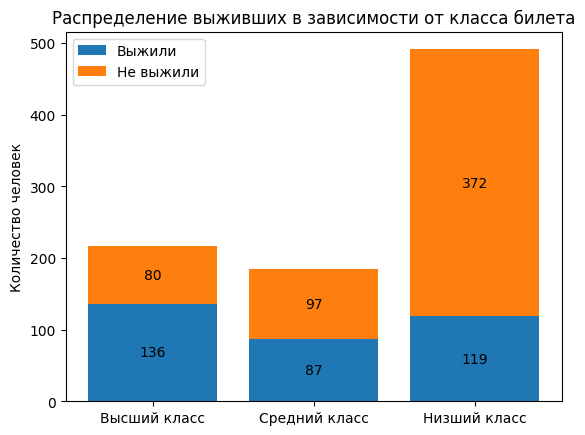

Процентое соотношение выживших:
Высший класс: 62.96%
Средний класс: 47.28%
Низший класс: 24.24%


In [ ]:
#Рассмотрим распределение выживших по классу билета
#Предполагается, что пассажиров с высоким классом билета среди выживших больше

# ============================================================
# АНАЛИЗ ВЫЖИВАЕМОСТИ В ЗАВИСИМОСТИ ОТ КЛАССА БИЛЕТА
# ============================================================

# ----- 1. Подсчет общего количества пассажиров в каждом классе -----
# Создаем булевы маски для фильтрации строк по классу билета (Pclass)
# df.loc[условие] - выбирает строки, где условие истинно
# len() - считает количество выбранных строк
class1_total = len(df.loc[df['Pclass'] == 1])    # Всего пассажиров в 1-м классе (высший)
class2_total = len(df.loc[df['Pclass'] == 2])    # Всего пассажиров во 2-м классе (средний)
class3_total = len(df.loc[df['Pclass'] == 3])    # Всего пассажиров в 3-м классе (низший)

# ----- 2. Подсчет выживших в каждом классе -----
# Используем составное условие с оператором & (логическое "И")
# Выбираем строки, где выживание = 1 И класс билета = соответствующий
class1_survived = len(df.loc[(df['Survived'] == 1) & (df['Pclass'] == 1)])  # Выжившие в 1-м классе
class2_survived = len(df.loc[(df['Survived'] == 1) & (df['Pclass'] == 2)])  # Выжившие во 2-м классе
class3_survived = len(df.loc[(df['Survived'] == 1) & (df['Pclass'] == 3)])  # Выжившие в 3-м классе

# ----- 3. Подготовка данных для визуализации (столбчатой диаграммы с накоплением) -----
# Создаем словарь, где ключи - категории (Выжили/Не выжили),
# а значения - списки с данными для каждого класса (1-й, 2-й, 3-й)
survivors_counts = {
    'Выжили': [class1_survived, class2_survived, class3_survived],           # Выжившие по классам
    'Не выжили': [class1_total - class1_survived,                            # Погибшие в 1-м классе
                  class2_total - class2_survived,                            # Погибшие во 2-м классе
                  class3_total - class3_survived]                            # Погибшие в 3-м классе
}

# ----- 4. Построение столбчатой диаграммы с накоплением -----
fig, ax = plt.subplots()                          # Создаем фигуру и оси для графика
bottom = np.zeros(3)                               # Начальные позиции для нижней части столбцов (для 3 классов)

# Цикл по категориям: сначала 'Выжили', потом 'Не выжили'
for name, value in survivors_counts.items():
    # Рисуем столбцы для текущей категории
    # ('Высший класс', 'Средний класс', 'Низший класс') - подписи по оси X
    # value - высота текущего сегмента для каждого класса
    # label=name - подпись для легенды ('Выжили' или 'Не выжили')
    # bottom=bottom - с какого уровня начинать рисовать сегмент
    column = ax.bar(('Высший класс', 'Средний класс', 'Низший класс'), 
                    value, label=name, bottom=bottom)
    
    # Увеличиваем bottom на высоту текущего сегмента для следующей категории
    # После первого прохода (Выжили) bottom станет равен [class1_survived, class2_survived, class3_survived]
    # Это позволит нарисовать сегмент 'Не выжили' прямо поверх 'Выжили'
    bottom += value
    
    # Добавляем числовые подписи в центр каждого сегмента столбца
    ax.bar_label(column, label_type='center')

# ----- 5. Оформление и отображение графика -----
ax.set_title('Распределение выживших в зависимости от класса билета')  # Заголовок графика
ax.set_ylabel('Количество человек')                                    # Подпись вертикальной оси Y
ax.legend()                                                            # Отображаем легенду (цветовые обозначения)
plt.show()                                                              # Показываем график на экране

# ----- 6. Расчет процентного соотношения для каждого класса -----
# Формула процента: (количество выживших в классе / общее количество в классе) * 100
percentage_class1_survived = (class1_survived / class1_total) * 100    # % выживших в 1-м классе
percentage_class2_survived = (class2_survived / class2_total) * 100    # % выживших во 2-м классе
percentage_class3_survived = (class3_survived / class3_total) * 100    # % выживших в 3-м классе

# ----- 7. Вывод результатов -----
print('Процентное соотношение выживших:')
print(f"Высший класс: {round(percentage_class1_survived, 2)}%")   # Округляем до 2 знаков после запятой
print(f"Средний класс: {round(percentage_class2_survived, 2)}%")
print(f"Низший класс: {round(percentage_class3_survived, 2)}%")

**Вывод: гипотеза подтвердилась - cуществует четкая зависимость между классом билета и шансами на выживание: чем выше класс билета - тем выше шанс выжить, что объясняется лучшим расположением кают первого класса ближе к шлюпкам и возможным социальным приоритетом при эвакуации, при этом разница между первым и третьим классом составляет почти 40 процентов.**

In [ ]:
#Рассмотрим распределение выживших в зависимости от класса билетов и от пола вместе
#Предполагается, что у женщин с высшим классом билета наивысший шанс выжить

# ============================================================
# АНАЛИЗ ВЫЖИВАЕМОСТИ В ЗАВИСИМОСТИ ОТ КЛАССА БИЛЕТА И ПОЛА
# ============================================================

# ----- 1. Подсчет общего количества пассажиров по комбинациям пола и класса -----
# groupby(['Pclass', 'Sex']) - группируем данные по двум признакам одновременно
# as_index=False - оставляем сгруппированные колонки как обычные колонки, не делаем их индексом
# agg({'PassengerId':'count'}) - для каждой группы считаем количество PassengerId (т.е. количество людей)
# rename(columns={'PassengerId':'TotalNumber'}) - переименовываем колонку для ясности
sex_class_total_df = df.groupby(['Pclass', 'Sex'], as_index=False) \
    .agg({'PassengerId': 'count'}) \
    .rename(columns={'PassengerId': 'TotalNumber'})

print("Общее количество пассажиров по полу и классу:")
print(sex_class_total_df)
print()

# ----- 2. Подсчет выживших пассажиров по комбинациям пола и класса -----
# df[df['Survived'] == 1] - сначала фильтруем ТОЛЬКО выживших пассажиров
# Затем группируем их по тем же признакам и считаем количество
sex_class_survived_df = df[df['Survived'] == 1].groupby(['Pclass', 'Sex'], as_index=False) \
    .agg({'PassengerId': 'count'}) \
    .rename(columns={'PassengerId': 'SurvivorsNumber'})

print("Количество выживших по полу и классу:")
print(sex_class_survived_df)
print()

# ----- 3. Объединение двух DataFrame'ов в один -----
# merge() - объединяет два DataFrame по общим колонкам ('Pclass', 'Sex')
# how='outer' - используем внешнее объединение, чтобы сохранить все комбинации
# fillna(0) - заполняем пропуски нулями (если в какой-то группе не было выживших)
sex_class_df = sex_class_total_df.merge(sex_class_survived_df, on=('Pclass', 'Sex'), how='outer').fillna(0)

print("Объединенные данные:")
print(sex_class_df)
print()

# ----- 4. Расчет процента выживших для каждой группы -----
# Добавляем новую колонку 'SurvivorsRate'
# Формула: (количество выживших / общее количество) * 100
# round(..., 2) - округляем до 2 знаков после запятой
sex_class_df['SurvivorsRate'] = round((sex_class_df['SurvivorsNumber'] / sex_class_df['TotalNumber']) * 100, 2)

print("Данные с процентом выживаемости:")
print(sex_class_df)
print()

# ----- 5. Подготовка данных для визуализации -----
# Создаем словарь, где ключи - классы, а значения - кортежи (процент мужчин, процент женщин)
values_dict = {
    'Высший класс': (
        sex_class_df[(sex_class_df['Sex'] == 'male') & (sex_class_df['Pclass'] == 1)]['SurvivorsRate'].values[0],
        sex_class_df[(sex_class_df['Sex'] == 'female') & (sex_class_df['Pclass'] == 1)]['SurvivorsRate'].values[0]
    ),
    'Средний класс': (
        sex_class_df[(sex_class_df['Sex'] == 'male') & (sex_class_df['Pclass'] == 2)]['SurvivorsRate'].values[0],
        sex_class_df[(sex_class_df['Sex'] == 'female') & (sex_class_df['Pclass'] == 2)]['SurvivorsRate'].values[0]
    ),
    'Низший класс': (
        sex_class_df[(sex_class_df['Sex'] == 'male') & (sex_class_df['Pclass'] == 3)]['SurvivorsRate'].values[0],
        sex_class_df[(sex_class_df['Sex'] == 'female') & (sex_class_df['Pclass'] == 3)]['SurvivorsRate'].values[0]
    ),
}

# ----- 6. Построение grouped bar chart (сгруппированной столбчатой диаграммы) -----
fig, ax = plt.subplots(figsize=(9, 6))

x = np.array([0, 1])      # Позиции для двух столбцов (мужчины, женщины)
number = 0                 # Счетчик для смещения групп

# Цикл по классам билетов
for name, value in values_dict.items():
    # Рисуем группу столбцов для текущего класса
    # x + 0.2*number - смещаем группу, чтобы они не накладывались друг на друга
    # value - проценты для мужчин и женщин в этом классе
    # width=0.2 - ширина каждого столбца
    column = ax.bar(x + 0.2 * number, value, 0.2, label=name)
    
    # Добавляем числовые подписи над каждым столбцом
    ax.bar_label(column)
    number += 1

# ----- 7. Оформление графика -----
ax.set_title('Проценты выживших пассажиров в зависимости от пола и класса билетов')
ax.set_ylabel('Процент')
ax.set_xticks(x + 0.2, ('Мужчины', 'Женщины'))  # Устанавливаем подписи оси X
ax.legend(loc='upper left', fontsize=11)
plt.show()

# ----- 8. Вывод итоговых выводов -----
print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ АНАЛИЗА")
print("="*60)
print(sex_class_df[['Pclass', 'Sex', 'TotalNumber', 'SurvivorsNumber', 'SurvivorsRate']])
print("="*60)
print("\nНаблюдение: Женщины высшего класса показали наивысшую выживаемость (96.81%),")

#Что означает каждая строка:

#Строка 0 (Pclass=1, Sex=female, TotalNumber=94):

#а борту было 94 женщины, которые путешествовали в 1-м (высшем) классе

#Строка 1 (Pclass=1, Sex=male, TotalNumber=122):

#На борту было 122 мужчины, которые путешествовали в 1-м (высшем) классе

#Что означает каждая строка:

#Строка 0 (Pclass=1, Sex=female, SurvivorsNumber=91):

#Из 94 женщин 1-го класса выжила 91

#Строка 1 (Pclass=1, Sex=male, SurvivorsNumber=45):

#Из 122 мужчин 1-го класса выжило 45
print("что подтверждает комбинированное влияние пола и социального статуса.")

   Pclass     Sex  TotalNumber
0       1  female           94
1       1    male          122
2       2  female           76
3       2    male          108
4       3  female          144
5       3    male          347

   Pclass     Sex  SurvivorsNumber
0       1  female               91
1       1    male               45
2       2  female               70
3       2    male               17
4       3  female               72
5       3    male               47


In [ ]:
sex_class_df = sex_class_total_df.merge(sex_class_survived_df, on =('Pclass', 'Sex'))
sex_class_df   #таблица с данными по полу и классу

#Здесь происходит объединение (merge) двух таблиц в одну
#Эта операция соединяет два DataFrame (sex_class_total_df и sex_class_survived_df) в один по общим колонкам Pclass и Sex.
#Как работает merge:
#on=('Pclass', 'Sex') - указывает, по каким колонкам соединять таблицы

#Для каждой уникальной комбинации (Pclass, Sex):

#Берется строка из первой таблицы

#Берется строка из второй таблицы с теми же значениями Pclass и Sex

#Они объединяются в одну строку

,Pclass,Sex,TotalNumber,SurvivorsNumber
0,1,female,94,91
1,1,male,122,45
2,2,female,76,70
3,2,male,108,17
4,3,female,144,72
5,3,male,347,47


In [ ]:
sex_class_df['SurvivorsRate'] = round((sex_class_df['SurvivorsNumber']/sex_class_df['TotalNumber'])*100, 2)
sex_class_df   #добавляет новую колонку в DataFrame и вычисляет для каждой группы процент выживаемости.

sex_class_df['SurvivorsNumber'] / sex_class_df['TotalNumber']:
Делит количество выживших на общее количество в каждой группе
Это поэлементная операция — для каждой строки делится соответствующее значение
Результат: доля выживших (например, 91/94 = 0.968085...)

* 100:
Умножает результат на 100, чтобы получить проценты

0.968085 * 100 = 96.8085%

round(..., 2):
Округляет результат до 2 знаков после запятой

96.8085 → 96.81

sex_class_df['SurvivorsRate'] = ...:

Создает в DataFrame новую колонку с названием SurvivorsRate

Заполняет ее вычисленными значениями

sex_class_df:

Выводит обновленный DataFrame на экран

,Pclass,Sex,TotalNumber,SurvivorsNumber,SurvivorsRate
0,1,female,94,91,96.81
1,1,male,122,45,36.89
2,2,female,76,70,92.11
3,2,male,108,17,15.74
4,3,female,144,72,50.00
5,3,male,347,47,13.54


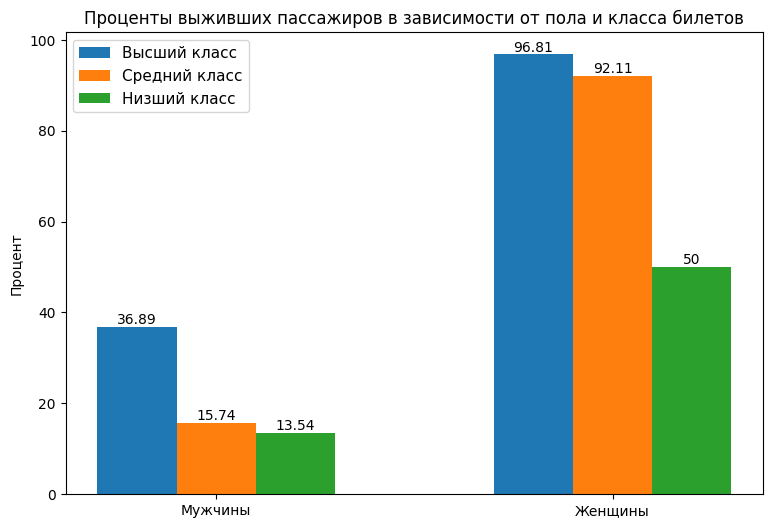

In [ ]:
#Визуализация
# ============================================================
# ВИЗУАЛИЗАЦИЯ: ПРОЦЕНТЫ ВЫЖИВШИХ ПО ПОЛУ И КЛАССУ
# ============================================================

# ----- 1. ПОДГОТОВКА ДАННЫХ ДЛЯ ВИЗУАЛИЗАЦИИ -----
# Создаем словарь, где ключи - названия классов,
# а значения - кортежи (процент мужчин, процент женщин) для каждого класса

values_dict = {
    'Высший класс': (
        # Извлекаем процент выживаемости мужчин 1-го класса
        # 1. Фильтруем DataFrame: пол = male И класс = 1
        # 2. Берем колонку 'SurvivorsRate'
        # 3. .values[0] извлекает первое (и единственное) значение
        sex_class_df[(sex_class_df['Sex'] == 'male') & (sex_class_df['Pclass'] == 1)]['SurvivorsRate'].values[0],
        
        # Извлекаем процент выживаемости женщин 1-го класса
        sex_class_df[(sex_class_df['Sex'] == 'female') & (sex_class_df['Pclass'] == 1)]['SurvivorsRate'].values[0]
    ),
    
    'Средний класс': (
        # Процент мужчин 2-го класса
        sex_class_df[(sex_class_df['Sex'] == 'male') & (sex_class_df['Pclass'] == 2)]['SurvivorsRate'].values[0],
        
        # Процент женщин 2-го класса
        sex_class_df[(sex_class_df['Sex'] == 'female') & (sex_class_df['Pclass'] == 2)]['SurvivorsRate'].values[0]
    ),
    
    'Низший класс': (
        # Процент мужчин 3-го класса
        sex_class_df[(sex_class_df['Sex'] == 'male') & (sex_class_df['Pclass'] == 3)]['SurvivorsRate'].values[0],
        
        # Процент женщин 3-го класса
        sex_class_df[(sex_class_df['Sex'] == 'female') & (sex_class_df['Pclass'] == 3)]['SurvivorsRate'].values[0]
    ),
}

# ----- 2. СОЗДАНИЕ ФИГУРЫ И ОСЕЙ -----
# figsize=(9, 6) - задаем размер графика (ширина 9 дюймов, высота 6 дюймов)
fig, ax = plt.subplots(figsize=(9, 6))

# ----- 3. НАСТРОЙКА ПОЗИЦИЙ ДЛЯ СТОЛБЦОВ -----
# x = [0, 1] - базовые позиции для двух групп: 0 = мужчины, 1 = женщины
x = np.array([0, 1])

# number - счетчик для смещения столбцов разных классов
# Будет принимать значения 0, 1, 2 для трех классов
number = 0

# ----- 4. ПОСТРОЕНИЕ СТОЛБЦОВ В ЦИКЛЕ -----
# Проходим по каждому классу в словаре values_dict
for name, value in values_dict.items():
    # Рисуем два столбца для текущего класса:
    # - Для мужчин: позиция x[0] + 0.2*number
    # - Для женщин: позиция x[1] + 0.2*number
    # value - кортеж с процентами (мужчины, женщины)
    # 0.2 - ширина каждого столбца
    # label=name - подпись для легенды
    column = ax.bar(x + 0.2 * number, value, 0.2, label=name)
    
    # Добавляем числовые подписи над каждым столбцом
    ax.bar_label(column)
    
    # Увеличиваем счетчик для следующего класса
    number += 1

# ----- 5. ОФОРМЛЕНИЕ ГРАФИКА -----
# Заголовок графика
ax.set_title('Проценты выживших пассажиров в зависимости от пола и класса билетов')

# Подпись оси Y
ax.set_ylabel('Процент')

# Устанавливаем подписи под группами столбцов
# x + 0.2 вычисляет позиции: [0+0.2, 1+0.2] = [0.2, 1.2]
# Это центры групп (посередине между столбцами разных классов)
ax.set_xticks(x + 0.2, ('Мужчины', 'Женщины'))

# Добавляем легенду в левый верхний угол с размером шрифта 11
ax.legend(loc='upper left', fontsize=11)

# Отображаем график
plt.show()

# ----- 6. ВЫВОД ИТОГОВЫХ ДАННЫХ ДЛЯ ПРОВЕРКИ -----
print("\n" + "="*60)
print("ДАННЫЕ ДЛЯ ВИЗУАЛИЗАЦИИ")
print("="*60)
for category, values in values_dict.items():
    print(f"{category}: Мужчины = {values[0]}%, Женщины = {values[1]}%")
print("="*60)

**Вывод: гипотеза подвтердилась - женщины высшего класса показали наивыысшую выживаемость (96.81%), женщины среднего класса также имели исключительно высокий показатель (92.11%), тогда как мужчины всех классов демонстрировали значительно более низкие результаты (от 13.54% в низшем до 36.89% в высшем классе), что подтверждает комбинированное влияние пола и социального статуса на шансы спасения.**

# Feature Engineering

In [ ]:
df.head()   #df.head() показывает первые 5 строк датафрейма. Это как "заглянуть" в таблицу, чтобы увидеть, как выглядят данные.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df['FamilySize'] = df['SibSp']+df['Parch']+1
# СОЗДАНИЕ ПРИЗНАКА "РАЗМЕР СЕМЬИ" (FamilySize) -----
# Формула: FamilySize = SibSp (братья/сестры + супруги) + Parch (родители/дети) + 1 (сам пассажир)
# Зачем: Вместо двух отдельных признаков (SibSp, Parch) получаем один общий - размер семьи
# Это может быть более информативно для модели

df['IsAlone'] = (df['FamilySize']==1).astype(int)
# СОЗДАНИЕ ПРИЗНАКА "ОДИНОЧКА" (IsAlone) -----
# Логика: Если FamilySize == 1, значит пассажир путешествует один
# (df['FamilySize'] == 1) - создает булеву маску (True/False)
# .astype(int) - преобразует True в 1, False в 0
# Зачем: Бинарный признак "один/не один" может быть полезнее, чем точный размер семьи

df.head()


Почему исходные признаки SibSp и Parch недостаточны?
Исходные признаки:

SibSp — количество братьев/сестер + супругов

Parch — количество родителей/детей

Проблема: Они разделяют семью на две части, но для выживания важнее общий размер семьи, а не ее состав.

Почему FamilySize (размер семьи) важен?
Логика:
В критической ситуации (тонущий корабль) поведение человека зависит от того, есть ли с ним семья:

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1


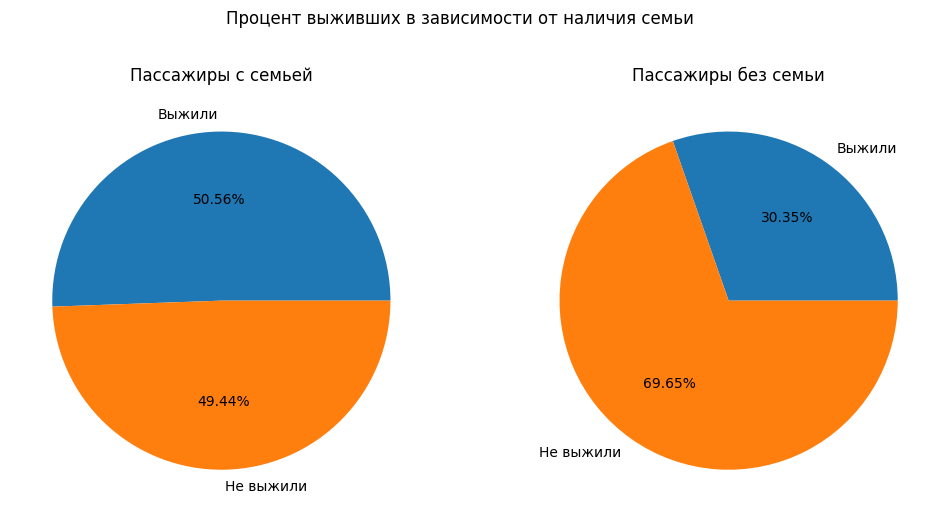

Количество выживших:
Выжило 179 из 354 пассажиров с семьей
Выжило 163 из 537 пассажиров без семьи


In [ ]:
#Рассмотрим распределение выживших среди пассажиров с семьей и одиноких пассиажиров
#Предполагается, что среди одиноких пассажиров выживших больше

alone_total = len(df.loc[df['IsAlone'] == 1])
not_alone_total = len(df.loc[df['IsAlone'] == 0])
alone_survived = len(df.loc[(df['Survived'] == 1) & (df['IsAlone'] == 1)])
not_alone_survived = len(df.loc[(df['Survived'] == 1) & (df['IsAlone'] == 0)])

#Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12,6))
fig.suptitle('Процент выживших в зависимости от наличия семьи')

ax1.pie([not_alone_survived, not_alone_total-not_alone_survived], labels = ('Выжили', 'Не выжили'), autopct='%1.2f%%')
ax1.set_title('Пассажиры с семьей')
ax2.pie([alone_survived, alone_total-alone_survived], labels = ('Выжили', 'Не выжили'), autopct='%1.2f%%')
ax2.set_title('Пассажиры без семьи')
plt.show()

print('Количество выживших:')
print(f"Выжило {not_alone_survived} из {not_alone_total} пассажиров с семьей")
print(f"Выжило {alone_survived} из {alone_total} пассажиров без семьи")



# ----- 1. ПОДСЧЕТ СТАТИСТИКИ -----
# Используем признаки, созданные на этапе Feature Engineering:
# IsAlone = 1 - пассажир путешествует один
# IsAlone = 0 - пассажир путешествует с семьей

# Подсчет общего количества пассажиров в каждой категории
# df.loc[условие] - выбирает строки, где условие истинно
# len() - считает количество выбранных строк
alone_total = len(df.loc[df['IsAlone'] == 1])              # Всего одиноких пассажиров
not_alone_total = len(df.loc[df['IsAlone'] == 0])          # Всего пассажиров с семьей

# Подсчет количества выживших в каждой категории
# Используем составное условие с оператором & (логическое "И")
# Выбираем строки, где Survived=1 (выжил) И IsAlone=1 (одинокий)
alone_survived = len(df.loc[(df['Survived'] == 1) & (df['IsAlone'] == 1)])        # Выжившие одиночки

# Выбираем строки, где Survived=1 (выжил) И IsAlone=0 (с семьей)
not_alone_survived = len(df.loc[(df['Survived'] == 1) & (df['IsAlone'] == 0)])    # Выжившие с семьей

**Вывод: гипотеза не подтвердилась - пассажиры с семьей имели значительно более высокие шансы на выживание (50.56% против 30.35% у одиноких), что свидетельствует о важности взаимопомощи и поддержки родственников в критической ситуации, при этом наличие семьи увеличивало вероятность спасения почти в 1.7 раза.**

In [ ]:
#Рассмотрим распределение выживших в зависимости от размера семьи
#Предполагается, что пассажиры с небольшим и средним размером семьи имеют больше шансов на выживание
family_total_df = df[df['FamilySize']!=1].groupby('FamilySize', as_index = False) \
    .agg({'PassengerId':'count'}) \
    .rename(columns={'PassengerId':'TotalNumber'})

family_survived_df = df[(df['FamilySize']!=1) & (df['Survived'] ==1)].groupby('FamilySize', as_index = False) \
    .agg({'PassengerId':'count'}) \
    .rename(columns={'PassengerId':'SurvivorsNumber'})

family_size_df = family_total_df.merge(family_survived_df, on='FamilySize', how='outer').fillna(0)
family_size_df['SurvivorsRate']=round((family_size_df['SurvivorsNumber']/family_size_df['TotalNumber'])*100, 2)
family_size_df

#Ранее мы сравнивали "одиноких" vs "с семьей" в целом. Теперь мы хотим понять, какой размер семьи оптимален для выживания. Влияет ли размер семьи на шансы?

family_total_df = df[df['FamilySize'] != 1].groupby('FamilySize', as_index=False) \
    .agg({'PassengerId': 'count'}) \
    .rename(columns={'PassengerId': 'TotalNumber'})
По шагам:

df[df['FamilySize'] != 1] — фильтруем данные, исключая одиноких пассажиров (FamilySize=1). Нас интересуют только те, у кого есть семья.

.groupby('FamilySize', as_index=False) — группируем отфильтрованные данные по размеру семьи. Создаются группы: FamilySize=2, 3, 4, 5, 6, 7, 8, 11.

.agg({'PassengerId': 'count'}) — для каждой группы считаем количество пассажиров (по уникальному PassengerId).

.rename(columns={'PassengerId': 'TotalNumber'}) — переименовываем колонку для ясности.

#Создание family_survived_df (количество выживших по размерам семьи)

family_survived_df = df[(df['FamilySize'] != 1) & (df['Survived'] == 1)].groupby('FamilySize', as_index=False) \
    .agg({'PassengerId': 'count'}) \
    .rename(columns={'PassengerId': 'SurvivorsNumber'})
По шагам:

(df['FamilySize'] != 1) & (df['Survived'] == 1) — составное условие:

Исключаем одиноких

Оставляем только выживших

.groupby('FamilySize', as_index=False) — группируем выживших по размеру семьи.

.agg({'PassengerId': 'count'}) — считаем количество выживших в каждой группе.

.rename(columns={'PassengerId': 'SurvivorsNumber'}) — переименовываем колонку.

#Объединение таблиц

family_size_df = family_total_df.merge(family_survived_df, on='FamilySize', how='outer').fillna(0)
.merge(..., on='FamilySize') — объединяет две таблицы по колонке FamilySize

how='outer' — внешнее объединение (сохраняет все размеры семьи из обеих таблиц)

.fillna(0) — заполняет пропуски нулями (для размеров семьи, где не было выживших)

Результат (family_size_df):

,FamilySize,TotalNumber,SurvivorsNumber,SurvivorsRate
0,2,161,89.0,55.28
1,3,102,59.0,57.84
2,4,29,21.0,72.41
3,5,15,3.0,20.00
4,6,22,3.0,13.64
5,7,12,4.0,33.33
6,8,6,0.0,0.00
7,11,7,0.0,0.00


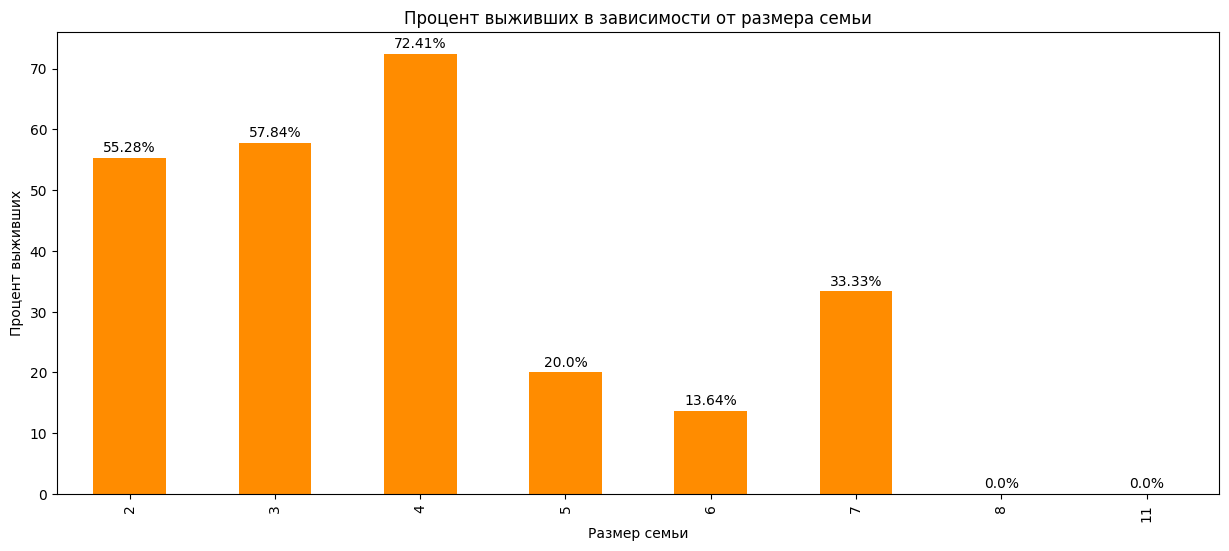

In [14]:
#Визуализация
family_size_df.plot(x='FamilySize', y='SurvivorsRate', kind = 'bar', figsize = (15,6), legend=False, color = 'darkorange')
plt.title('Процент выживших в зависимости от размера семьи')
plt.xlabel('Размер семьи')
plt.ylabel('Процент выживших')
for (index, row) in family_size_df.iterrows():
    plt.text(index, row['SurvivorsRate']+1, f'{row["SurvivorsRate"]}%', ha='center')
plt.show()

**Вывод: гипотеза подтвердилась - оптимальными для выживания оказались семьи размером 2-4 человека (выживаемость 55-72%), тогда как очень большие семьи (5+ человек) показывали резкое снижение показателей, что может объясняться трудностями координации и эвакуации больших групп людей в экстренной ситуации.**

In [15]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1


In [ ]:
# Рассмотрим титулы пассажиров
# Предполагается, что пассажиры с титулами высокой значимости имеют более высокие шансы на выживание

# Извлекаем титул из имени пассажира
# str.split(',') - разбиваем строку по запятой, берем первую часть (фамилия)
# .str[1] - берем вторую часть после запятой (имя и титул)
# .str.split('.') - разбиваем по точке, чтобы отделить титул от имени
# .str[0] - берем первую часть (титул)
# .str.strip() - удаляем лишние пробелы в начале и конце
df['Title'] = df['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()

# Сгруппируем одинаковые по смыслу титулы
# Mme (Madame) заменяем на Mrs (замужняя женщина)
# Ms и Mlle (Mademoiselle) заменяем на Miss (незамужняя женщина)
df['Title'] = df['Title'].replace({'Mme': 'Mrs', 'Ms': 'Miss', 'Mlle': 'Miss'})

# Расставим степень социальной значимости каждому титулу
# Создаем словарь, где ключ - название титула, значение - ранг (1 - наивысший, 14 - наинизший)
title_ranks = {
    'the Countess': 1,   # графиня - высший аристократический титул
    'Sir': 2,            # рыцарь - дворянский титул
    'Lady': 3,           # леди - дворянский титул
    'Don': 4,            # дон - испанский дворянский титул
    'Jonkheer': 5,       # дворянин (нидерландский титул)
    'Capt': 6,           # капитан судна - военное звание
    'Col': 7,            # полковник армии - военное звание
    'Major': 8,          # майор армии - военное звание
    'Dr': 9,             # доктор - ученая степень
    'Rev': 10,           # священник - религиозный титул
    'Mrs': 11,           # замужняя женщина
    'Miss': 12,          # незамужняя женщина
    'Master': 13,        # мальчик (обращение к юноше)
    'Mr': 14             # мужчина (самый распространенный титул)
}

# Создаем новый столбец 'Rank', присваивая каждому титулу его ранг из словаря
# map() заменяет каждый титул соответствующим значением из словаря
df['Rank'] = df['Title'].map(title_ranks)

# Группируем данные по титулу и рангу для подсчета общего количества пассажиров
# groupby(['Title', 'Rank']) - группируем по двум колонкам
# as_index=False - оставляем колонки как обычные колонки, не делаем их индексом
# agg({'PassengerId':'count'}) - для каждой группы считаем количество пассажиров
# rename(columns={'PassengerId':'TotalNumber'}) - переименовываем колонку для ясности
title_total_df = df.groupby(['Title', 'Rank'], as_index=False) \
    .agg({'PassengerId': 'count'}) \
    .rename(columns={'PassengerId': 'TotalNumber'})

# Фильтруем только выживших пассажиров, затем группируем по титулу и рангу
# df.loc[df['Survived'] == 1] - выбираем только строки с выжившими
# groupby(['Title', 'Rank']) - группируем выживших по титулу и рангу
# agg({'PassengerId':'count'}) - считаем количество выживших в каждой группе
# rename(columns={'PassengerId':'SurvivorsNumber'}) - переименовываем колонку
title_survivors_df = df.loc[df['Survived'] == 1].groupby(['Title', 'Rank'], as_index=False) \
    .agg({'PassengerId': 'count'}) \
    .rename(columns={'PassengerId': 'SurvivorsNumber'})

# Объединяем две таблицы в одну
# merge() - объединяет DataFrame'ы по общим колонкам ('Title', 'Rank')
# how='outer' - используем внешнее объединение, чтобы сохранить все титулы
# fillna(0) - заполняем пропуски нулями (для титулов, где не было выживших)
title_df = title_survivors_df.merge(title_total_df, on=['Title', 'Rank'], how='outer').fillna(0)

# Переставляем колонки в удобном порядке и сортируем по рангу
# [['Rank', 'Title', 'SurvivorsNumber', 'TotalNumber']] - выбираем колонки в указанном порядке
# sort_values('Rank') - сортируем строки по возрастанию ранга (от 1 до 14)
title_df = title_df[['Rank', 'Title', 'SurvivorsNumber', 'TotalNumber']].sort_values('Rank')

# Рассчитываем процент выживших для каждого титула
# SurvivorsNumber / TotalNumber - доля выживших
# * 100 - переводим в проценты
# round(..., 2) - округляем до 2 знаков после запятой
# Создаем новый столбец 'SurvivorsRate' с полученными значениями
title_df['SurvivorsRate'] = round(title_df['SurvivorsNumber'] / title_df['TotalNumber'] * 100, 2)

# Выводим итоговую таблицу
title_df

,Rank,Title,SurvivorsNumber,TotalNumber,SurvivorsRate
13,1,the Countess,1.0,1,100.00
12,2,Sir,1.0,1,100.00
5,3,Lady,1.0,1,100.00
2,4,Don,0.0,1,0.00
4,5,Jonkheer,0.0,1,0.00
0,6,Capt,0.0,1,0.00
1,7,Col,1.0,2,50.00
6,8,Major,1.0,2,50.00
3,9,Dr,3.0,7,42.86
11,10,Rev,0.0,6,0.00


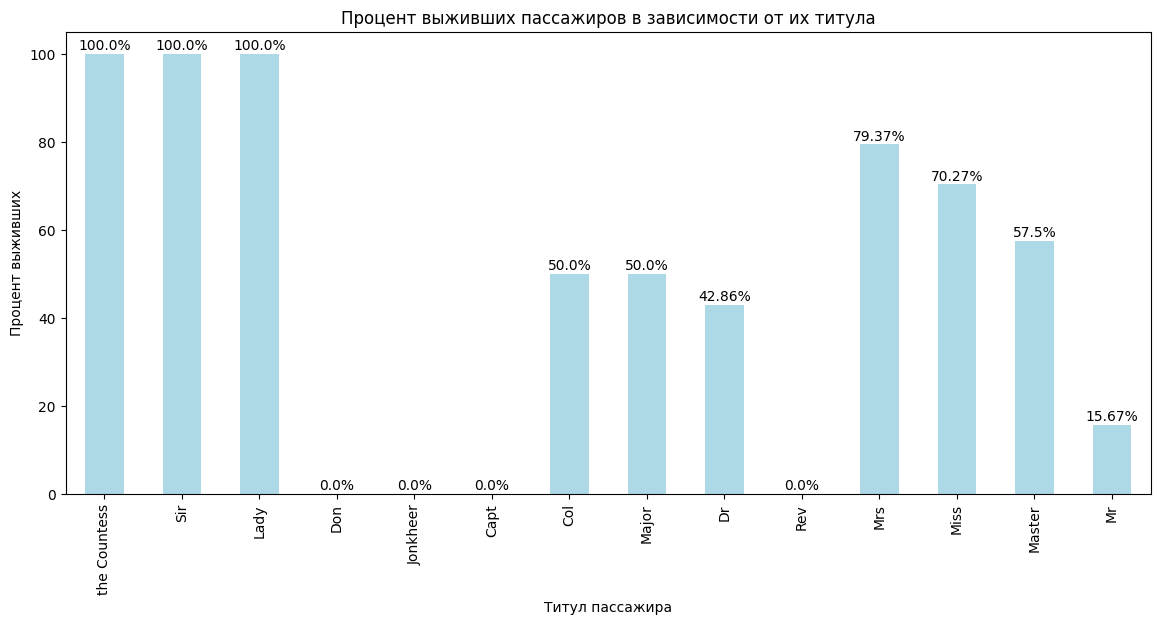

In [ ]:
# Визуализация: столбчатая диаграмма для процента выживших по титулам

# Используем встроенный метод plot() DataFrame для быстрого построения графика
# title_df.plot() - вызываем метод plot у DataFrame title_df
# x='Title' - используем колонку 'Title' для значений по оси X (подписи столбцов)
# y='SurvivorsRate' - используем колонку 'SurvivorsRate' для значений по оси Y (высота столбцов)
# figsize=(14, 6) - задаем размер графика: ширина 14 дюймов, высота 6 дюймов
# kind='bar' - тип графика: столбчатая диаграмма (bar chart)
# legend=False - отключаем легенду (она не нужна, так как у нас только один набор данных)
# color='lightblue' - задаем цвет столбцов (светло-голубой)
title_df.plot(x='Title', y='SurvivorsRate', figsize=(14, 6), kind='bar', legend=False, color='lightblue')

# Добавляем заголовок к графику
# title() - задает заголовок, который отображается над графиком
plt.title('Процент выживших пассажиров в зависимости от их титула')

# Добавляем подпись к оси X (горизонтальная ось)
# xlabel() - задает текст под осью X
plt.xlabel('Титул пассажира')

# Добавляем подпись к оси Y (вертикальная ось)
# ylabel() - задает текст рядом с осью Y
plt.ylabel('Процент выживших')

# Добавляем числовые подписи над каждым столбцом
# enumerate(title_df.iterrows()) - проходим по строкам DataFrame с индексом
# iterrows() - возвращает пару (индекс, данные строки) для каждой строки
for i, (index, row) in enumerate(title_df.iterrows()):
    # plt.text() - добавляет текст в указанную позицию на графике
    # i - координата X (позиция столбца, 0, 1, 2, 3...)
    # row['SurvivorsRate'] + 1 - координата Y (чуть выше верхней границы столбца)
    # f"{row['SurvivorsRate']}%" - текст для отображения (значение процента с символом %)
    # ha='center' - выравнивание текста по центру относительно координаты X
    plt.text(i, row['SurvivorsRate'] + 1, f"{row['SurvivorsRate']}%", ha='center')

# Отображаем график
# show() - выводит график на экран
plt.show()

**Вывод: гипотеза подтвердилась частично - три высших титула действительно показали 100% выживаемость, однако в целом приоритет отдавался женщинам и детям независимо от социального статуса (Mrs - 79.37%, Miss - 70.17%, Master - 57.14%), что демонстрирует преобладание гендерного и возрастного факторов над чисто социальным статусом**

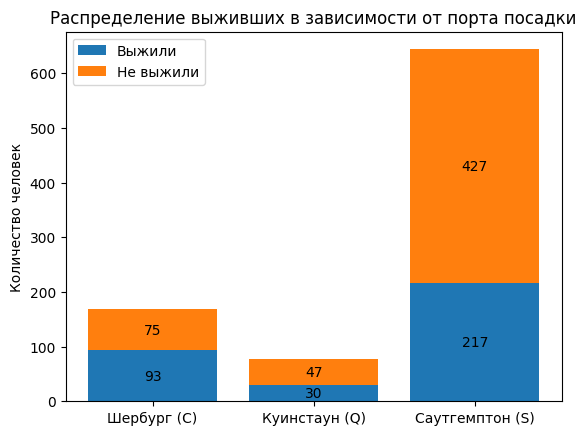

Процентое соотношение выживших:
Порт Шербург (C): 55.36%
Порт Куинстаун (Q): 38.96%
Порт Саутгемптон (S): 33.7%


In [ ]:
# Рассмотрим распределение выживших в зависимости от порта посадки
# Предполагается, что пассажиров, которые производили посадку с одного из портов больше, чем с остальных портов

# ----- 1. ПОДСЧЕТ ОБЩЕГО КОЛИЧЕСТВА ПАССАЖИРОВ ПО ПОРТАМ -----
# df.loc[df['Embarked'] == 'C'] - выбираем строки, где порт посадки = C (Шербург)
# len() - считаем количество таких строк
port1_total = len(df.loc[df['Embarked'] == 'C'])  # Всего пассажиров из порта Шербург (C)

# df.loc[df['Embarked'] == 'Q'] - выбираем строки, где порт посадки = Q (Куинстаун)
port2_total = len(df.loc[df['Embarked'] == 'Q'])  # Всего пассажиров из порта Куинстаун (Q)

# df.loc[df['Embarked'] == 'S'] - выбираем строки, где порт посадки = S (Саутгемптон)
port3_total = len(df.loc[df['Embarked'] == 'S'])  # Всего пассажиров из порта Саутгемптон (S)

# ----- 2. ПОДСЧЕТ ВЫЖИВШИХ ПО КАЖДОМУ ПОРТУ -----
# Используем составное условие с оператором & (логическое "И")
# Выбираем строки, где выживание = 1 И порт посадки = C
port1_survived = len(df.loc[(df['Survived'] == 1) & (df['Embarked'] == 'C')])  # Выжившие из порта C

# Выбираем строки, где выживание = 1 И порт посадки = Q
port2_survived = len(df.loc[(df['Survived'] == 1) & (df['Embarked'] == 'Q')])  # Выжившие из порта Q

# Выбираем строки, где выживание = 1 И порт посадки = S
port3_survived = len(df.loc[(df['Survived'] == 1) & (df['Embarked'] == 'S')])  # Выжившие из порта S

# ----- 3. ПОДГОТОВКА ДАННЫХ ДЛЯ ВИЗУАЛИЗАЦИИ -----
# Создаем словарь для построения столбчатой диаграммы с накоплением
# Ключи - категории ('Выжили', 'Не выжили')
# Значения - списки с данными для каждого порта [C, Q, S]
survivors_counts = {
    'Выжили': [port1_survived, port2_survived, port3_survived],      # Выжившие по портам
    'Не выжили': [port1_total - port1_survived,                       # Погибшие в порту C
                  port2_total - port2_survived,                       # Погибшие в порту Q
                  port3_total - port3_survived]                       # Погибшие в порту S
}

# ----- 4. СОЗДАНИЕ ФИГУРЫ И ОСЕЙ -----
# plt.subplots() - создает фигуру и оси для графика
fig, ax = plt.subplots()

# bottom = np.zeros(3) - создает массив из трех нулей [0, 0, 0]
# Эта переменная будет отслеживать, с какой высоты начинать рисовать следующий сегмент
bottom = np.zeros(3)

# ----- 5. ПОСТРОЕНИЕ СТОЛБЧАТОЙ ДИАГРАММЫ С НАКОПЛЕНИЕМ -----
# Цикл по категориям: сначала 'Выжили', потом 'Не выжили'
for name, value in survivors_counts.items():
    # ax.bar() - рисует столбцы для текущей категории
    # ('Шербург (C)', 'Куинстаун (Q)', 'Саутгемптон (S)') - подписи по оси X
    # value - высота текущего сегмента для каждого порта
    # label=name - подпись для легенды ('Выжили' или 'Не выжили')
    # bottom=bottom - с какого уровня начинать рисовать сегмент
    column = ax.bar(('Шербург (C)', 'Куинстаун (Q)', 'Саутгемптон (S)'), 
                    value, label=name, bottom=bottom)
    
    # Увеличиваем bottom на высоту текущего сегмента для следующей категории
    # После первого прохода (Выжили) bottom станет равен [port1_survived, port2_survived, port3_survived]
    bottom += value
    
    # Добавляем числовые подписи в центр каждого сегмента столбца
    # label_type='center' - размещает подпись по центру сегмента
    ax.bar_label(column, label_type='center')

# ----- 6. ОФОРМЛЕНИЕ ГРАФИКА -----
# Заголовок графика
ax.set_title('Распределение выживших в зависимости от порта посадки')

# Подпись вертикальной оси Y
ax.set_ylabel('Количество человек')

# Отображаем легенду (обозначения цветов: 'Выжили' и 'Не выжили')
ax.legend()

# Отображаем график
plt.show()

# ----- 7. РАСЧЕТ ПРОЦЕНТНОГО СООТНОШЕНИЯ -----
# Формула процента: (выжившие в порту / всего в порту) * 100
percentage_port1_survived = (port1_survived / port1_total) * 100  # % выживших из порта C
percentage_port2_survived = (port2_survived / port2_total) * 100  # % выживших из порта Q
percentage_port3_survived = (port3_survived / port3_total) * 100  # % выживших из порта S

# ----- 8. ВЫВОД РЕЗУЛЬТАТОВ -----
print('Процентное соотношение выживших:')
print(f"Порт Шербург (C): {round(percentage_port1_survived, 2)}%")      # Округляем до 2 знаков
print(f"Порт Куинстаун (Q): {round(percentage_port2_survived, 2)}%")
print(f"Порт Саутгемптон (S): {round(percentage_port3_survived, 2)}%")

**Гипотеза подтвердилась - выживаемость для каждого порта посадки отличается, самая высокая - у порта Шербург. Рассмотрим подробнее, что могло на это повлиять.**

In [ ]:
#Рассмотрим подробнее, что могло повлиять на выживаемость для каждого порта посадки
survived_df = df[df['Survived'] == 1]
#df[df['Survived'] == 1] — фильтрует исходный DataFrame, оставляя только выживших пассажиров
#survived_df — новый DataFrame, содержащий только 342 строки (выживших)

embarked_df = survived_df.groupby('Embarked').agg({
    'PassengerId': 'count',
    'Age': ['mean', lambda x: (x < 18).mean()],
    'Fare': 'mean',
    'Pclass': lambda x: (x == 1).mean(),
    'Sex': lambda x: (x == 'female').mean(),
    'FamilySize': 'mean'}).round(3)
#Что делает:
#survived_df — берет только выживших пассажиров
#.groupby('Embarked') — группирует их по порту посадки (C, Q, S)
#.agg({...}) — для каждой группы считает статистику:

#'PassengerId': 'count'
#Считает количество выживших пассажиров в каждом порту
#Результат: колонка TotalSurvivors

#'Age': ['mean', lambda x: (x < 18).mean()]
#'mean' — средний возраст выживших в каждом порту
#lambda x: (x < 18).mean() — доля детей (младше 18) среди выживших
#(x < 18) — создает булеву маску (True для детей, False для взрослых)
#.mean() — вычисляет среднее (долю True, т.е. процент детей)

#'Fare': 'mean'
#Средняя стоимость билета среди выживших в каждом порту

#'Pclass': lambda x: (x == 1).mean()
#Доля выживших, которые путешествовали в 1-м классе (высший класс)
#(x == 1) — маска для пассажиров 1-го класса
#.mean() — вычисляет долю

#'Sex': lambda x: (x == 'female').mean()
#Доля женщин среди выживших в каждом порту
#(x == 'female') — маска для женщин
#.mean() — вычисляет долю

#'FamilySize': 'mean'
#Средний размер семьи среди выживших в каждом порту

#round(3)
#Округляет все полученные значения до 3 знаков после запятой

embarked_df.columns = ['TotalSurvivors', 'AverageAge', 'ProportionKids', 'AverageFare', 
    'ProportionHighPClass', 'ProportionWomen', 'AverageFamilySize']
#Присваиваем колонкам понятные имена:
#TotalSurvivors — общее количество выживших
#AverageAge — средний возраст выживших
#ProportionKids — доля детей среди выживших
#AverageFare — средняя стоимость билета
#ProportionHighPClass — доля пассажиров 1-го класса
#ProportionWomen — доля женщин
#AverageFamilySize — средний размер семьи

embarked_df

**Вывод: разница в выживаемости между портами (55.36% в Шербурге против 33.7% в Саутгемптоне) не находит однозначного объяснения в анализируемых факторах. Например, гендерный состав не объясняет эту разницу - в Куинстауне с наименьшей выживаемостью (38.96%) был самый высокий процент женщин (90%), тогда как в Шербурге женщин было меньше (68.8%), но выживаемость выше. Аналогично, средний размер семьи и доля детей практически одинаковы во всех портах, что также не проясняет причин различий. Это свидетельствует о том, что на выживаемость влияли скрытые факторы, либо комбинации нескольких характеристик**

# Рассчет коэфицентов корреляции с таргетом

In [ ]:
Что такое корреляция и зачем она нужна?
Корреляция — это статистическая мера связи между двумя переменными
Представьте, что вы хотите понять, связаны ли два явления:

Положительная корреляция — когда одна переменная растет, другая тоже растет (например, рост и вес)

Отрицательная корреляция — когда одна переменная растет, другая уменьшается (например, скорость и время в пути)

Нулевая корреляция — связи нет

Значения корреляции:
от -1 до 0 — обратная связь (чем больше X, тем меньше Y)

0 — связи нет

от 0 до +1 — прямая связь (чем больше X, тем больше Y)

Зачем это нужно в нашем анализе?
Мы хотим понять, какие признаки сильнее всего влияют на выживаемость (Survived). Это поможет:

Понять данные — подтвердить или опровернуть гипотезы

Выбрать признаки для модели машинного обучения

Упростить модель — убрать признаки, которые не влияют на результат

Три метода корреляции
Автор использует три разных метода:

Метод	Для чего	Особенности
Пирсон	Линейная связь между числами	Чувствителен к выбросам
Спирмен	Монотонная связь (не обязательно линейная)	Работает с рангами
Кендалл	Связь между порядковыми переменными	Устойчив к выбросам



# ============================================================
# РАСЧЕТ КОЭФФИЦИЕНТОВ КОРРЕЛЯЦИИ С ТАРГЕТОМ (ВЫЖИВАЕМОСТЬЮ)
# ============================================================

# ----- 1. ПОДГОТОВКА ДАННЫХ ДЛЯ КОРРЕЛЯЦИОННОГО АНАЛИЗА -----
# Создаем копию DataFrame только с нужными колонками
# Это позволит рассчитать корреляцию между Survived и другими признаками
correlation_df = df[['Survived', 'Sex', 'Age', 'Pclass', 'Rank', 'FamilySize', 'Fare', 'Embarked', 'IsAlone']].copy()

# Заполняем пропуски в колонке возраста медианным значением
# Корреляция не работает с пропусками (NaN), поэтому нужно их заполнить
# Медиана выбрана, потому что она устойчива к выбросам
correlation_df['Age'] = correlation_df['Age'].fillna(correlation_df['Age'].median())

# Преобразуем пол в числа (0 - мужчина, 1 - женщина)
# Корреляция работает только с числами, поэтому текстовые значения нужно кодировать
# male -> 0, female -> 1
correlation_df.loc[correlation_df['Sex'] == 'male', 'Sex'] = 0
correlation_df.loc[correlation_df['Sex'] == 'female', 'Sex'] = 1

# Преобразуем порт посадки в числа (1 - Шербург, 2 - Куинстаун, 3 - Саутгемптон)
# Это порядковая кодировка, хотя порты не имеют естественного порядка
correlation_df.loc[correlation_df['Embarked'] == 'C', 'Embarked'] = 1  # Шербург
correlation_df.loc[correlation_df['Embarked'] == 'Q', 'Embarked'] = 2  # Куинстаун
correlation_df.loc[correlation_df['Embarked'] == 'S', 'Embarked'] = 3  # Саутгемптон

# ----- 2. РАСЧЕТ КОРРЕЛЯЦИИ ТРЕМЯ РАЗНЫМИ МЕТОДАМИ -----

# Метод Пирсона - измеряет линейную связь между переменными
# Самый распространенный метод, но чувствителен к выбросам
# .loc['Survived'] - берем только корреляции с целевой переменной
# .drop('Survived') - убираем корреляцию Survived с самим собой (всегда 1)
corr_coeffs_pearson = correlation_df.corr('pearson').loc['Survived'].drop('Survived').round(3)

# Метод Спирмена - измеряет монотонную связь (не обязательно линейную)
# Использует ранги значений вместо самих значений, менее чувствителен к выбросам
corr_coeffs_spearman = correlation_df.corr('spearman').loc['Survived'].drop('Survived').round(3)

# Метод Кендалла - измеряет порядковую связь
# Хорошо подходит для категориальных данных, устойчив к выбросам
corr_coeffs_kendall = correlation_df.corr('kendall').loc['Survived'].drop('Survived').round(3)

# ----- 3. ВЫВОД РЕЗУЛЬТАТОВ -----
print(f'\nКоэффициенты корреляции с признаком Survived с помощью метода Пирсона:')
print(corr_coeffs_pearson)
print(f'\nКоэффициенты корреляции с признаком Survived с помощью метода Спирмена:')
print(corr_coeffs_spearman)
print(f'\nКоэффициенты корреляции с признаком Survived с помощью метода Кендалла:')
print(corr_coeffs_kendall)

# ----- 4. ВИЗУАЛИЗАЦИЯ КОРРЕЛЯЦИЙ (ПИРСОН) -----
# Строим столбчатую диаграмму для коэффициентов Пирсона
corr_coeffs_pearson.plot(figsize=(12, 6), kind='bar')
plt.title('Коэффициенты корреляции с признаком Survived по Пирсону')
plt.xlabel('Признак')
plt.ylabel('Коэффициент')
plt.grid(alpha=0.2)

# Добавляем числовые подписи над каждым столбцом
for index, value in enumerate(corr_coeffs_pearson):
    # Смещаем подпись чуть выше для положительных значений и чуть ниже для отрицательных
    offset = 0.01 if value >= 0 else -0.03
    plt.text(index, value + offset, f'{value}', ha='center')
plt.show()

# ----- 5. ВИЗУАЛИЗАЦИЯ КОРРЕЛЯЦИЙ (СПИРМЕН) -----
corr_coeffs_spearman.plot(figsize=(12, 6), kind='bar', color='red')
plt.title('Коэффициенты корреляции с признаком Survived по Спирмену')
plt.xlabel('Признак')
plt.ylabel('Коэффициент')
plt.grid(alpha=0.2)

for index, value in enumerate(corr_coeffs_spearman):
    offset = 0.01 if value >= 0 else -0.03
    plt.text(index, value + offset, f'{value}', ha='center')
plt.show()

# ----- 6. ВИЗУАЛИЗАЦИЯ КОРРЕЛЯЦИЙ (КЕНДАЛЛ) -----
corr_coeffs_kendall.plot(figsize=(12, 6), kind='bar', color='green')
plt.title('Коэффициенты корреляции с признаком Survived по Кендаллу')
plt.xlabel('Признак')
plt.ylabel('Коэффициент')
plt.grid(alpha=0.2)

for index, value in enumerate(corr_coeffs_kendall):
    offset = 0.01 if value >= 0 else -0.03
    plt.text(index, value + offset, f'{value}', ha='center')
plt.show()
print(corr_coeffs_kendall)


Коэфиценты кореляций с признаком Survived с помощью метода Пирсона:
Sex           0.543
Age          -0.065
Pclass       -0.338
Rank         -0.438
FamilySize    0.017
Fare          0.257
Embarked     -0.170
IsAlone      -0.203
Name: Survived, dtype: float64

Коэфиценты кореляций с признаком Survived с помощью метода Спирмена:
Sex           0.543
Age          -0.037
Pclass       -0.340
Rank         -0.533
FamilySize    0.165
Fare          0.324
Embarked     -0.162
IsAlone      -0.203
Name: Survived, dtype: float64

Коэфиценты кореляций с признаком Survived с помощью метода Кендалла:
Sex           0.543
Age          -0.031
Pclass       -0.324
Rank         -0.501
FamilySize    0.155
Fare          0.266
Embarked     -0.158
IsAlone      -0.203
Name: Survived, dtype: float64


В анализе "Титаника" использовали три метода (Пирсона, Спирмена, Кендалла), потому что каждый метод показывает связь с разных сторон. Один метод может "не заметить" зависимость, которую увидят другие.

Кратко о каждом методе
Метод	Что измеряет	Когда лучше
Пирсон	Линейную связь	Данные нормальные, связь прямая
Спирмен	Монотонную связь	Есть выбросы, связь нелинейная
Кендалл	Порядковую связь	Мало данных, категориальные признаки
Пример из Титаника — почему важно использовать все три
Признак FamilySize (размер семьи)
Метод	Коэффициент	Что говорит
Пирсон	0.017	"Связи почти нет"
Спирмен	0.165	"Связь есть!"
Кендалл	0.155	"Связь есть!"
Почему так? Зависимость не линейная:

Семья 2-4 человека → шансы выше

Одинокий → шансы ниже

Большая семья (5+) → шансы падают

Линейный Пирсон не уловил эту связь, а Спирмен и Кендалл уловили!

Вывод
Использование трех методов — это перестраховка. Если все три показывают одинаковый результат — можно быть уверенным. Если результаты расходятся — значит, связь есть, но она не линейная.




Разница между методами корреляции простыми словами
Представьте, что у нас есть два ряда чисел, и мы хотим понять, связаны ли они между собой. Три метода делают это немного по-разному.

Метод Пирсона (самый распространенный)
Что измеряет: Насколько строго точки ложатся на прямую линию.

Простыми словами: Пирсон смотрит, можно ли провести прямую линию через облако точек и насколько точки близки к этой линии.

Когда использовать: Когда связь между признаками линейная и равномерная.

Примеры из жизни:

✅ Рост и вес — чем выше человек, тем больше вес (примерно линейно)

✅ Количество часов подготовки и результат экзамена

Недостаток: Очень чувствителен к выбросам. Одно аномальное значение может сильно исказить результат.

Метод Спирмена
Что измеряет: Насколько хорошо можно описать связь монотонной функцией (не обязательно прямой линией).

Простыми словами: Спирмен переводит числа в ранги (1-е место, 2-е место, 3-е место...) и смотрит, растут ли ранги вместе.

Когда использовать: Когда связь есть, но она не обязательно линейная, или есть выбросы.

Примеры из жизни:

✅ Возраст и скорость бега — сначала растет, потом падает (не линейно, но монотонно?)

✅ Уровень образования и доход — чем выше образование, тем выше доход (в среднем)

Преимущество: Менее чувствителен к выбросам, потому что работает с рангами.

Метод Кендалла
Что измеряет: Насколько вероятно, что при увеличении X увеличивается и Y.

Простыми словами: Кендалл смотрит на все пары точек и считает, сколько из них "согласованы" (обе растут или обе падают) против "несогласованных" (одна растет, другая падает).

Когда использовать: Когда данных мало или когда нужно проверить порядковую связь.

Примеры из жизни:

✅ Оценки студентов (A, B, C, D) и их рейтинг

✅ Категории товаров (эконом, стандарт, премиум) и качество

Преимущество: Самый устойчивый к выбросам, хорошо работает с категориальными данными.

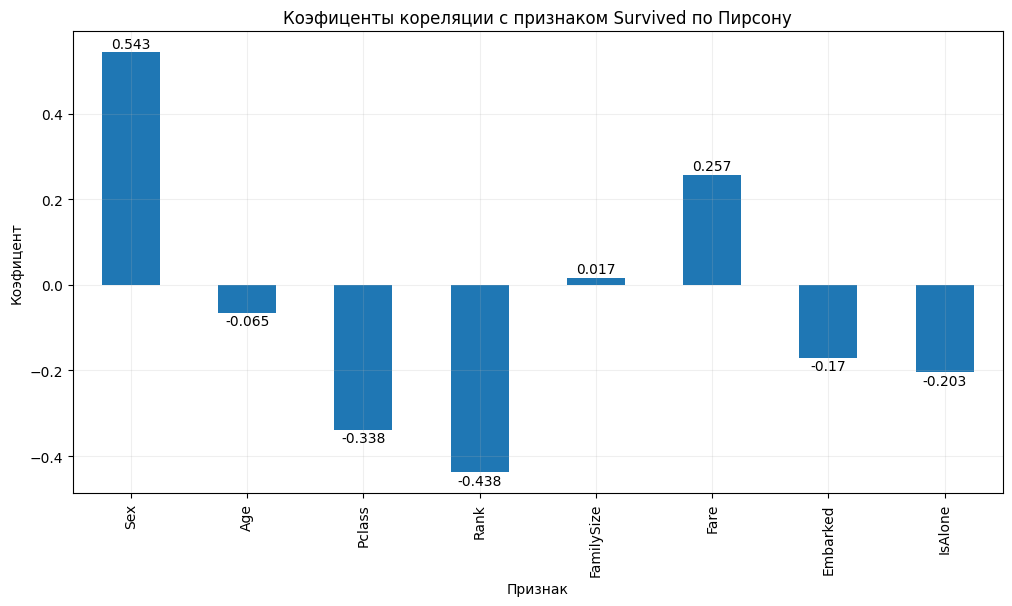

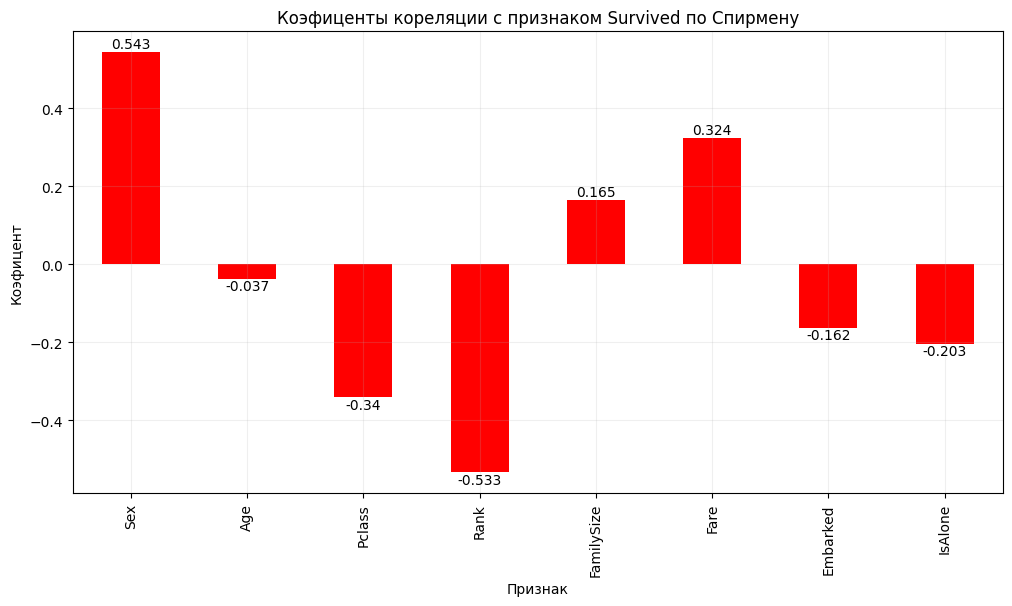

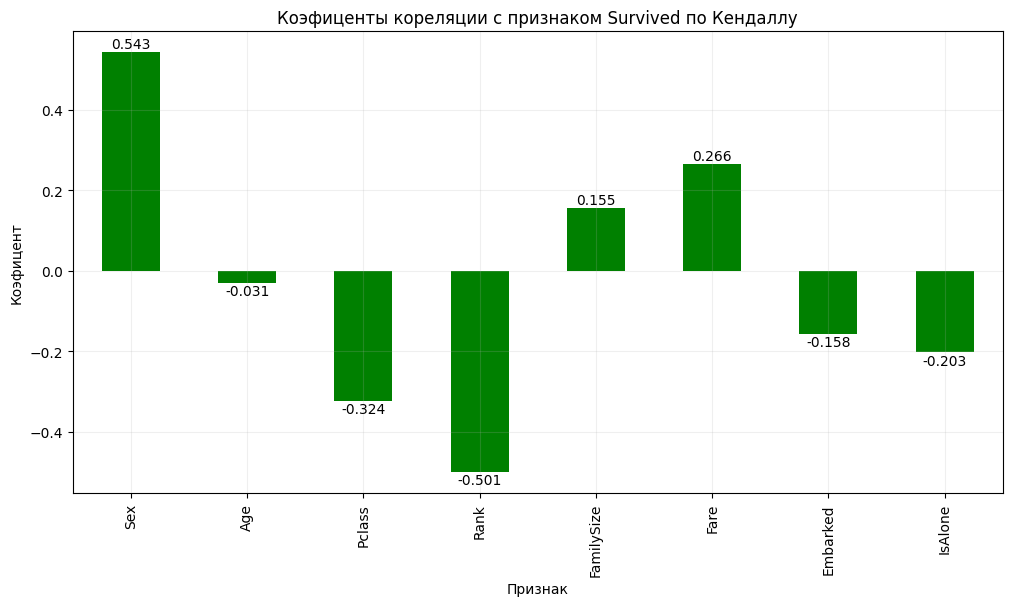

In [ ]:
# ============================================================
# ВИЗУАЛИЗАЦИЯ КОЭФФИЦИЕНТОВ КОРРЕЛЯЦИИ
# Три графика для трех методов: Пирсон, Спирмен, Кендалл
# ============================================================

# ----- 1. ВИЗУАЛИЗАЦИЯ КОЭФФИЦИЕНТОВ ПИРСОНА -----

# Используем встроенный метод plot() Series для построения столбчатой диаграммы
# corr_coeffs_pearson - это Series с коэффициентами корреляции Пирсона
# figsize=(12, 6) - задаем размер графика: ширина 12 дюймов, высота 6 дюймов
# kind='bar' - тип графика: столбчатая диаграмма (bar chart)
corr_coeffs_pearson.plot(figsize=(12, 6), kind='bar')

# Добавляем заголовок к графику
# title() - задает заголовок, который отображается над графиком
plt.title('Коэффициенты корреляции с признаком Survived по Пирсону')

# Добавляем подпись к оси X (горизонтальная ось)
# xlabel() - задает текст под осью X
plt.xlabel('Признак')

# Добавляем подпись к оси Y (вертикальная ось)
# ylabel() - задает текст рядом с осью Y
plt.ylabel('Коэффициент')

# Добавляем сетку для лучшей читаемости
# alpha=0.2 - прозрачность сетки (20%, чтобы не перекрывала столбцы)
plt.grid(alpha=0.2)

# Добавляем числовые подписи над каждым столбцом
# enumerate() - проходит по элементам с индексом (0, 1, 2...)
for index, value in enumerate(corr_coeffs_pearson):
    # Определяем смещение для подписи
    # Если значение положительное - ставим чуть выше столбца
    # Если отрицательное - ставим чуть ниже столбца (чтобы не налезало на столбец)
    offset = 0.01 if value >= 0 else -0.03
    
    # plt.text() - добавляет текст в указанную позицию на графике
    # index - координата X (позиция столбца)
    # value + offset - координата Y (чуть выше или ниже верхней границы столбца)
    # f'{value}' - текст для отображения (значение коэффициента)
    # ha='center' - выравнивание текста по центру относительно координаты X
    plt.text(index, value + offset, f'{value}', ha='center')

# Отображаем первый график
plt.show()

# ----- 2. ВИЗУАЛИЗАЦИЯ КОЭФФИЦИЕНТОВ СПИРМЕНА -----

# Строим столбчатую диаграмму для коэффициентов Спирмена
# color='red' - задаем красный цвет столбцов (чтобы отличать от первого графика)
corr_coeffs_spearman.plot(figsize=(12, 6), kind='bar', color='red')

# Заголовок для второго графика
plt.title('Коэффициенты корреляции с признаком Survived по Спирмену')

# Подпись оси X
plt.xlabel('Признак')

# Подпись оси Y
plt.ylabel('Коэффициент')

# Сетка с прозрачностью 20%
plt.grid(alpha=0.2)

# Добавляем числовые подписи над каждым столбцом (аналогично первому графику)
for index, value in enumerate(corr_coeffs_spearman):
    # Определяем смещение в зависимости от знака значения
    offset = 0.01 if value >= 0 else -0.03
    # Добавляем текст с значением коэффициента
    plt.text(index, value + offset, f'{value}', ha='center')

# Отображаем второй график
plt.show()

# ----- 3. ВИЗУАЛИЗАЦИЯ КОЭФФИЦИЕНТОВ КЕНДАЛЛА -----

# Строим столбчатую диаграмму для коэффициентов Кендалла
# color='green' - задаем зеленый цвет столбцов
corr_coeffs_kendall.plot(figsize=(12, 6), kind='bar', color='green')

# Заголовок для третьего графика
plt.title('Коэффициенты корреляции с признаком Survived по Кендаллу')

# Подпись оси X
plt.xlabel('Признак')

# Подпись оси Y
plt.ylabel('Коэффициент')

# Сетка с прозрачностью 20%
plt.grid(alpha=0.2)

# Добавляем числовые подписи над каждым столбцом
for index, value in enumerate(corr_coeffs_kendall):
    # Определяем смещение в зависимости от знака значения
    offset = 0.01 if value >= 0 else -0.03
    # Добавляем текст с значением коэффициента
    plt.text(index, value + offset, f'{value}', ha='center')

# Отображаем третий график
plt.show()

**Вывод: анализ корреляций тремя методами показал, что наибольшее влияние на выживаемость оказывает пол пассажира (коэффициент 0.543), что свидетельствует о сильной прямой зависимости - женщины имели более высокие шансы на выживание. Ранг титула демонстрирует обратную корреляцию в диапазоне -0.44 до -0.53. Класс билета показывает умеренную обратную зависимость (около -0.33), подтверждая приоритет спасения пассажиров высших классов. Стоимость билета имеет слабую прямую корреляцию (в среднем 0.28), что логично связывает ее с классом билета. Размер семьи, ее отсутсвие и порт посадки имеют слабые связи (в среднем 0.11, -0.203 и -0.16 соответственно), а возраст практически не коррелирует с выживаемостью (в среднем -0.04).**

# Подготовка данных к построению моделей обучения

In [ ]:
#Убираем дублирующиеся признаки (название титула и его ранг), оставляем начальные признаки и фичи (FamiliSize, IsAlone, Rank)
df = df.drop(columns = ['Title'])
df.head()

Автор объясняет, что сейчас он удалит дублирующиеся признаки. У нас есть два признака, связанных с титулом:

Title — текстовое название (Mr, Mrs, Miss...)

Rank — числовой ранг (1, 2, 3...)

Для модели машинного обучения нужен только один из них, потому что:

Они содержат одинаковую информацию (ранг полностью определяется титулом)

Использование обоих может привести к мультиколлинеарности (когда признаки сильно коррелируют друг с другом)

Rank уже в числовом формате, а Title еще нужно кодировать

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Rank
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,14
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,11
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,12
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,11
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,14


In [ ]:
#Общая информация
print(df['Survived'].value_counts()) #Что делает: Считает, сколько строк имеет значение 0 и сколько значение 1 в колонке Survived.
#Почему это важно:
#Показывает, что у нас несбалансированные классы (549 погибших, 342 выживших)
#Это значит, что если модель всегда будет предсказывать "погиб", она будет права в 61.6% случаев
#Нужно учитывать это при выборе метрик (accuracy может быть обманчива)


print('\nРазмеры датасета:')
print(df.shape)  #Что делает: Выводит размер DataFrame в формате (строки, колонки).
#Почему это важно:
#Показывает, что у нас 891 строка и 15 колонок
#Это исходный размер данных, с которым мы работаем
#Позже, после удаления признаков, размер может измениться

print("\nПропуски:")
print(df.isnull().sum())
#Что делает:
#df.isnull() — создает DataFrame из True/False, где True означает пропуск
#.sum() — суммирует True по каждой колонке (сколько пропусков)

print("\nТипы данных:")
print(df.dtypes)
#Почему это важно:
Модели машинного обучения работают только с числами
Нужно знать, какие колонки текстовые (object), чтобы потом их закодировать
В нашем случае текстовые: Name, Sex, Ticket, Cabin, Embarked

Остальные колонки уже числовые и готовы к использованию

Зачем нужна общая информация?
Перед тем как строить модель, нужно понять, с какими данными мы работаем:
Сколько данных у нас есть
Какие типы данных в каждой колонке
Есть ли пропуски и сколько их
Сбалансирован ли целевой признак (сколько выживших и погибших)




Почему это важно:

Большинство моделей не умеют работать с пропусками

Нужно знать, где есть пропуски, чтобы решить, что с ними делать:

Заполнить (медианой, средним, модой)

Удалить строки

Удалить колонки

В Age 177 пропусков — нужно заполнить

В Cabin 687 пропусков (почти 80%) — вероятно, колонку удалят

В Embarked 2 пропуска — можно заполнить модой

Survived
0    549
1    342
Name: count, dtype: int64

Размеры датасета:
(891, 15)

Пропуски:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
IsAlone          0
Rank             0
dtype: int64

Типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
FamilySize       int64
IsAlone          int64
Rank             int64
dtype: object


In [ ]:
#Выбираем категориальные признаки
categorial_features = df.select_dtypes(include = ['object']).columns
label_encoders = {}
categorial_features

По шагам:
df.select_dtypes(include=['object'])
select_dtypes() — метод pandas для выбора колонок по типу данных
include=['object'] — указываем, что хотим выбрать только колонки типа object (текстовые)

.columns
Извлекает имена выбранных колонок

categorial_features = ...
Сохраняет эти имена в переменную categorial_features


Создает пустой словарь label_encoders, который будет хранить объекты-кодировщики для каждой категориальной колонки.

Зачем это нужно?

Когда мы кодируем текст в числа, нам нужно запомнить, какое число соответствует какому тексту

Например: male → 0, female → 1

Эти кодировщики понадобятся позже, если мы захотим преобразовать новые данные (например, тестовую выборку) так же, как обучающую

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [ ]:
#Векторизация
from sklearn.preprocessing import LabelEncoder  #Импортируем класс LabelEncoder из библиотеки sklearn.preprocessing. Это специальный инструмент для преобразования текстовых меток в числа.
for features in categorial_features: #Проходим по всем категориальным признакам, которые мы определили ранее: 
#Name — имя пассажира
#Sex — пол
#Ticket — номер билета
#Cabin — номер каюты
#Embarked — порт посадки

#Создаем новый объект LabelEncoder для текущей колонки. Каждая колонка получает свой собственный кодировщик, потому что у каждой колонки свои уникальные значения.
    le = LabelEncoder()
    
    df[features] = le.fit_transform(df[features])
    #fit_transform() делает две вещи одновременно:
#fit() — изучает уникальные значения в колонке и создает соответствие "текст → число"
#transform() — применяет это соответствие ко всем значениям, заменяя текст на числа
    label_encoders[features] = le
    Сохраняем созданный кодировщик в словарь label_encoders под именем колонки.
Зачем сохранять?
Когда мы будем делать предсказания на новых данных (например, на тестовой выборке), нам нужно преобразовать их точно так же
Мы используем сохраненный кодировщик с помощью transform() (без fit), чтобы новые данные получили те же числа
df.head()


#Модели машинного обучения не понимают текст. Они работают только с числами. Поэтому все текстовые колонки нужно преобразовать в числа. Этот процесс называется векторизацией или кодированием (encoding).




,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Rank
0,1,0,3,108,1,22.0,1,0,523,7.2500,147,2,2,0,14
1,2,1,1,190,0,38.0,1,0,596,71.2833,81,0,2,0,11
2,3,1,3,353,0,26.0,0,0,669,7.9250,147,2,1,1,12
3,4,1,1,272,0,35.0,1,0,49,53.1000,55,2,2,0,11
4,5,0,3,15,1,35.0,0,0,472,8.0500,147,2,1,1,14


Как работает LabelEncoder:

Берет уникальные текстовые значения в колонке

Присваивает каждому уникальному значению число от 0 до N-1

Запоминает это соответствие
['male', 'female', 'female', 'male']  →  [0, 1, 1, 0]

Label Encoding (то, что использовал автор)
Как работает: Каждой категории присваивается уникальное число.

text
['male', 'female', 'female', 'male'] → [0, 1, 1, 0]
Результат: Одна колонка с числами.

One-Hot Encoding
Как работает: Создает отдельную колонку для каждой категории со значениями 0 или 1.

text
['male', 'female', 'female', 'male'] → 
   male  female
    1      0
    0      1
    0      1
    1      0
Результат: Несколько колонок (по количеству уникальных значений).

Почему автор выбрал Label Encoding для этих конкретных признаков?
1. Для признака Sex (пол)
Метод	Результат	Проблема
Label Encoding	male → 0, female → 1	OK
One-Hot Encoding	male_col, female_col	Избыточно (2 колонки вместо 1)
Почему Label Encoding подходит: Пол — это бинарный признак (всего 2 значения). Label Encoding создает одну колонку, что эффективно. Модель легко поймет, что 0 и 1 — это просто разные категории, а не порядок.

2. Для признака Embarked (порт посадки)
| Значения | C (Шербург), Q (Куинстаун), S (Саутгемптон) |

Label Encoding создает одну колонку: C→0, Q→1, S→2

One-Hot Encoding создал бы 3 колонки: Embarked_C, Embarked_Q, Embarked_S

Почему Label Encoding может быть проблематичным:

Модель может подумать, что S (2) > Q (1) > C (0)

Но это просто разные порты, никакого порядка между ними нет

Модель может ошибочно решить, что "чем выше число, тем лучше"

3. Для признаков Name, Ticket, Cabin
Это признаки с огромным количеством уникальных значений:

Признак	Уникальных значений
Name	891 (почти все уникальны)
Ticket	~680 уникальных
Cabin	~150 уникальных
Если бы мы использовали One-Hot Encoding:

Для Name — 891 новая колонка! Это катастрофа (проклятие размерности)

Для Ticket — ~680 новых колонок

Для Cabin — ~150 новых колонок

Общий размер данных стал бы тысячи колонок, модель бы переобучилась и работала очень медленно

Label Encoding создает всего 1 колонку для каждого признака, что эффективно по памяти и скорости.

Почему Label Encoding — не всегда идеальный выбор?
Проблема 1: Создание ложного порядка
Для признаков без естественного порядка (как Embarked) Label Encoding может создать ложную порядковую связь:

Модель может решить, что S (2) важнее, чем C (0)

На самом деле это просто разные порты

Проблема 2: Для линейных моделей
Линейные модели (логистическая регрессия) могут неправильно интерпретировать закодированные числа:

Они думают, что 2 > 1 > 0 в математическом смысле

Для таких моделей One-Hot Encoding часто лучше

Почему автор все равно выбрал Label Encoding?
Посмотрим, какие модели автор будет использовать дальше:

Модель	Чувствительность к порядку
Логистическая регрессия	Высокая (может быть проблема)
Решающее дерево	Низкая (деревья ищут пороговые значения, порядок не важен)
XGBoost	Низкая (градиентный бустинг тоже ищет пороги)
Нейронная сеть	Средняя (может обучиться, если порядок не важен)
Автор планирует использовать древовидные модели (Random Forest, XGBoost), которые не чувствительны к порядку категорий. Для них Label Encoding работает отлично.

Альтернативный подход
Можно было бы использовать разные методы для разных признаков:

Признак	Лучший метод	Почему
Sex	Label Encoding	Бинарный признак
Embarked	One-Hot Encoding	Нет порядка между портами
Name/Ticket/Cabin	Label Encoding	Слишком много уникальных значений
Но автор упростил и использовал Label Encoding для всех, потому что:

Это проще (один цикл для всех колонок)

Древовидные модели все равно справятся

One-Hot Encoding для Name создал бы 891 колонку — это неприемлемо

Автор выбрал Label Encoding, потому что:

У него много признаков с огромным количеством уникальных значений

Он планирует использовать древовидные модели, которым все равно на порядок

Это эффективно по памяти и просто в реализации

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    int64  
 4   Sex          891 non-null    int64  
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    int64  
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    int64  
 11  Embarked     891 non-null    int64  
 12  FamilySize   891 non-null    int64  
 13  IsAlone      891 non-null    int64  
 14  Rank         891 non-null    int64  
dtypes: float64(2), int64(13)
memory usage: 104.5 KB


2. Проверка, что все колонки закодированы в числа
Обратите внимание на типы данных:

Было (до кодирования)	Стало (после)
Name: object (текст)	Name: int64 (число)
Sex: object (текст)	Sex: int64 (число)
Ticket: object (текст)	Ticket: int64 (число)
Cabin: object (текст)	Cabin: int64 (число)
Embarked: object (текст)	Embarked: int64 (число)
Вывод: Все текстовые колонки успешно преобразованы в числа! Это означает, что данные готовы для подачи в модель.

3. Проверка пропусков
Посмотрим на колонку Age:

text
Age    714 non-null    float64
Всего строк: 891

Непустых значений в Age: 714

Пропусков: 177 (891 - 714 = 177)

Проблема: В Age все еще есть пропуски! Модели не умеют работать с пропусками.

Что нужно сделать: Заполнить пропуски в возрасте (например, медианным значением).

In [ ]:
#Заполним пропуски в возрасте медианным значением
df['Age'] = df['Age'].fillna(df['Age'].median())
df.isnull().sum()

#df['Age'].median() — вычисляет медиану (центральное значение) всех возрастов в датасете
#.fillna(...) — метод pandas, который заменяет все пропуски (NaN) указанным значением
#df['Age'] = ... — присваивает результат обратно в колонку Age, перезаписывая ее

#df.isnull() — создает DataFrame из True/False, где True означает пропуск
#.sum() — суммирует True по каждой колонке (количество пропусков)
#Выводит результат, чтобы убедиться, что пропусков больше нет



PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
FamilySize     0
IsAlone        0
Rank           0
dtype: int64

Что такое медиана?
Медиана — это "среднее" значение в упорядоченном ряду чисел. Половина чисел меньше медианы, половина — больше.

Пример: [5, 7, 12, 18, 45] → медиана = 12

Почему медиана, а не среднее?
Метод	Формула	Пример [10, 20, 30, 40, 1000]
Среднее (mean)	Сумма / количество	(10+20+30+40+1000)/5 = 220
Медиана (median)	Центральное значение	30
Проблема среднего: Очень чувствительно к выбросам. Если есть один очень богатый пожилой пассажир, средний возраст сильно исказится.

Преимущество медианы: Устойчива к выбросам. Дает более "типичное" значение.
Какие еще есть варианты?
Метод	Как работает	Плюсы	Минусы	Когда использовать

Медиана	Центральное значение	Устойчива к выбросам	Не учитывает распределение	Когда есть выбросы

Среднее (mean)	Сумма / количество	Учитывает все значения	Чувствительно к выбросам	Когда данные нормально распределены

Мода (mode)	Самое частое значение	Хорошо для категорий	Может быть несколько мод	Для категориальных данных

Константа	Например, 0 или -1	Просто	Может исказить данные	Когда пропуски имеют особый смысл

Групповое среднее	Среднее по группе (например, по классу)	Учитывает контекст	Сложнее реализовать	Когда данные имеют группы

Вперед/назад заполнение	Берет следующее/предыдущее значение	Сохраняет тренд	Только для упорядоченных данных	Для временных рядов

Интерполяция	Математическое приближение	Плавное заполнение	Сложно	Для временных рядов

Почему в нашем случае медиана — лучший выбор?
1. В данных есть выбросы
Самый молодой пассажир — 0.17 лет (младенец)
Самый старый пассажир — 80 лет
Среднее может быть искажено, медиана — нет.

2. Возраст не имеет явных групп
Можно было бы заполнять по группам (например, средний возраст мужчин 1-го класса), но это сложнее, а медиана по всем данным — простой и эффективный метод.

3. Медиана уже вычислена в датасете
Из предыдущего анализа мы знаем, что медианный возраст пассажиров — 28 лет.


In [ ]:
# Импортируем функцию для разделения данных на обучающую и тестовую выборки
# train_test_split случайным образом перемешивает и делит данные  функция для разделения данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Импортируем класс для стандартизации данных (масштабирования)
# StandardScaler приводит все признаки к единому масштабу (среднее=0, std=1)
from sklearn.preprocessing import StandardScaler

# ----- 1. ВЫДЕЛЕНИЕ ТАРГЕТА (ЦЕЛЕВОЙ ПЕРЕМЕННОЙ) -----
# Создаем матрицу признаков X: берем весь DataFrame, но удаляем колонку 'Survived'
# drop(columns=['Survived']) - удаляем целевую переменную из признаков
# В X остаются только входные данные (возраст, пол, класс и т.д.)
X = df.drop(columns=['Survived'])

# Создаем целевую переменную Y: берем только колонку 'Survived'
# Это то, что мы хотим предсказывать (0 - погиб, 1 - выжил)
Y = df['Survived']

# ----- 2. РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ -----
# train_test_split случайным образом перемешивает и разделяет данные
# X - матрица признаков, Y - целевая переменная
# test_size=0.2 - 20% данных пойдет в тестовую выборку, 80% - в обучающую
# random_state=42 - фиксирует "зерно" случайности для воспроизводимости результатов
#   (при каждом запуске разделение будет одинаковым)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Результат разделения:
# X_train - 80% данных для обучения модели (признаки)
# X_test  - 20% данных для проверки модели (признаки)
# Y_train - 80% данных для обучения (правильные ответы)
# Y_test  - 20% данных для проверки (правильные ответы)

# ----- 3. СТАНДАРТИЗАЦИЯ ДАННЫХ (МАСШТАБИРОВАНИЕ) -----
# Создаем объект StandardScaler
# Этот объект будет вычислять параметры стандартизации (среднее и std)
scaler = StandardScaler()

# fit_transform() для ОБУЧАЮЩЕЙ выборки:
# 1. fit() - вычисляет среднее и стандартное отклонение по обучающим данным
# 2. transform() - применяет преобразование к обучающим данным
# Формула: (x - mean) / std
# После преобразования каждый признак имеет среднее = 0 и стандартное отклонение = 1
X_train = scaler.fit_transform(X_train)

# transform() для ТЕСТОВОЙ выборки:
# Применяем те же самые параметры (среднее и std из обучающей выборки)
# Мы НЕ должны использовать информацию из тестовой выборки при обучении!
# Это предотвращает "подглядывание" модели в будущие данные
X_test = scaler.transform(X_test)

# Теперь данные готовы для подачи в модели машинного обучения!
# X_train, Y_train - для обучения
# X_test, Y_test - для проверки качества модели

Что такое стандартизация?
Стандартизация — это процесс преобразования данных так, чтобы они имели среднее значение = 0 и стандартное отклонение = 1.

Формула стандартизации:
text
z = (x - mean) / std
Где:
x — исходное значение
mean — среднее значение признака
std — стандартное отклонение
z — стандартизованное значение

Наглядный пример
Представьте, что у нас есть два признака:

До стандартизации:
Пассажир	Возраст (Age)	Стоимость билета (Fare)
1	22 года	$7.25
2	38 лет	$71.28
3	26 лет	$7.92
4	35 лет	$53.10
5	35 лет	$8.05
Проблема:

Возраст: от 0 до 80 лет

Цена билета: от 0 до 512 долларов

Модель может ошибочно решить, что цена билета важнее возраста, просто потому что числа больше!

После стандартизации:
Пассажир	Возраст (Age)	Стоимость билета (Fare)
1	-0.5	-0.3
2	0.8	1.2
3	-0.3	-0.3
4	0.5	0.8
5	0.5	-0.3
Результат: Оба признака теперь в одном масштабе. Модель будет оценивать их важность объективно.
Без стандартизации модель может подумать, что Fare (числа до 512) важнее, чем Age (числа до 80).



Метод	Что делает	Формула	Когда использовать
StandardScaler	Приводит к среднему 0 и дисперсии 1	(x - mean) / std	Для линейных моделей, нейросетей, SVM
MinMaxScaler	Приводит к диапазону [0, 1]	(x - min) / (max - min)	Когда данные не имеют выбросов, нужно сохранить границы
RobustScaler	Использует медиану и IQR	(x - median) / IQR	Когда есть выбросы — устойчив к ним
MaxAbsScaler	Масштабирует к диапазону [-1, 1]	x / max(	x	)	Для разреженных данных (sparse)
Normalizer	Нормализует по строкам	x /	x			Когда важны направления векторов (например, текстовые данные)

# Feature Importance

In [ ]:
from sklearn.ensemble import RandomForestRegressor
#Импортируем Random Forest Regressor — модель на основе множества решающих деревьев.
#Почему Random Forest?
#Автоматически вычисляет важность признаков
#Устойчив к переобучению
#Работает с любыми типами данных

#Обучаем простую модель RandomForest для анализа важности признаков
rf_model = RandomForestRegressor(n_estimators=50, random_state=42)

#Обучаем модель на подготовленных данных:
#X_train — признаки (возраст, пол, класс и т.д.)
#Y_train — целевая переменная (выживаемость) В процессе обучения каждое дерево ищет лучшие split'ы, и на основе этого вычисляется важность признаков.
rf_model.fit(X_train, Y_train)

#Создаем DataFrame с важностью признаков
#X.columns — берем названия всех признаков (колонок)
#rf_model.feature_importances_ — получаем массив с важностью каждого признака (сумма всех важностей = 1)
#pd.DataFrame({...}) — создаем таблицу с двумя колонками
#.sort_values('importance', ascending=False) — сортируем от самого важного к наименее важному

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
feature_importance

,feature,importance
13,Rank,0.213571
2,Name,0.126183
3,Sex,0.109354
7,Ticket,0.107383
8,Fare,0.093268
0,PassengerId,0.084442
4,Age,0.076633
1,Pclass,0.075197
9,Cabin,0.047254
11,FamilySize,0.038430


Этот код использует Random Forest для оценки важности признаков. Давайте разберем, зачем это нужно и как работает.

Зачем нужен анализ важности признаков?
1. Понимание данных
Мы хотим узнать, какие факторы действительно влияют на выживаемость. Это подтверждает или опровергает наши гипотезы из EDA.

2. Отбор признаков для модели
Можно убрать признаки, которые не влияют на результат. Это:
Упрощает модель
Ускоряет обучение
Уменьшает риск переобучения

50 — это количество деревьев, из которых состоит "случайный лес" (Random Forest).

Простая аналогия
Представьте, что вы хотите принять важное решение (например, купить машину). Вы спрашиваете совета у экспертов:

Количество экспертов	Результат
1 эксперт	Может ошибаться или быть предвзятым
10 экспертов	Уже лучше, но может не хватить
50 экспертов	Хороший баланс — много мнений, но не слишком долго ждать

42
# Без random_state
X_train, X_test = train_test_split(X, test_size=0.2)
# При каждом запуске данные делятся ПО-РАЗНОМУ!

# С random_state=42
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
# При каждом запуске данные делятся ОДИНАКОВО!
Зачем это нужно?
Воспроизводимость результатов — другие люди (или вы через месяц) получат те же результаты

Честное сравнение моделей — можно сравнивать модели, зная, что они обучались на одинаковых данных

Отладка — легче находить ошибки, если данные не меняются

Сплит (split) — это разделение данных на две части по какому-то условию. В контексте деревьев решений это вопрос, который разделяет пассажиров на две группы.
Как дерево решений выбирает лучший сплит?
Дерево ищет вопрос, который лучше всего разделяет выживших и погибших.

Плохой сплит:
text
    Класс = 3?
    ├──→ Да (491 человек) → [30% выживших, 70% погибших]
    └──→ Нет (400 человек) → [50% выживших, 50% погибших]
Обе группы все еще смешанные — плохое разделение.

Хороший сплит:
text
    Пол = женский?
    ├──→ Да (314 женщин) → [74% выживших, 26% погибших]
    └──→ Нет (577 мужчин) → [19% выживших, 81% погибших]
Группы стали "чище" — хорошее разделение!

**Вывод: анализ важности признаков показал, что наименьшее влияние имеют количество родствнников и статус "одиночки" - их важность составляет менее 1 процента. Эти маловажные признаки будут исключены из финальной модели для упрощения и ускорения обучения.**

In [ ]:
#Убираем таргет и неважные признаки (важность < 1%)
X_final = df.drop(columns=['Survived', 'SibSp', 'Parch', 'IsAlone'])

#Создаем финальную выборку
X_temp, X_test, Y_temp, Y_test = train_test_split(X_final, Y, test_size=0.2, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.25, random_state=42)

#Стандартизация финальной выборки
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Зачем нужно три выборки?
Выборка	Назначение	Когда используется
Train (обучение)	Модель учится на этих данных	На каждой эпохе обучения
Validation (валидация)	Проверяем качество во время обучения, настраиваем гиперпараметры	После каждой эпохи
Test (тест)	Финальная проверка на новых данных	Только один раз в конце

Почему нужно перемешивать?
Без перемешивания мы могли бы взять, например, первые 80% пассажиров для обучения. Но в исходных данных пассажиры могут быть упорядочены по классам или другим признакам. Это привело бы к смещенной выборке.

Плохо (без перемешивания):
text
[1 класс] [1 класс] [1 класс] [2 класс] [2 класс] [3 класс] [3 класс]
  Train (первые 80%)           Test (последние 20%)
  ↑ только 1 и 2 класс         ↑ только 3 класс
  Модель не увидит 3 класс!     
Хорошо (с перемешиванием):
text
[3 класс] [1 класс] [2 класс] [3 класс] [2 класс] [1 класс] [3 класс]
  Train (первые 80%)           Test (последние 20%)
  ↑ все классы                  ↑ все классы
  Модель видит все классы

Этот код создает финальный набор данных для обучения моделей, удаляя неважные признаки и разделяя данные на три части: обучающую, валидационную и тестовую. Давайте разберем подробно.
Почему мы удалили Survived?
Это ключевой момент в подготовке данных для машинного обучения. Давайте разберем подробно.

Главная причина: разделение на вход и выход
В машинном обучении мы всегда разделяем данные на:

Тип	Что это	Пример
X (признаки / features)	Входные данные	Возраст, пол, класс, цена билета
Y (цель / target)	То, что хотим предсказать	Survived (выжил/погиб)
Образно говоря:
X — это вопросы на экзамене

Y — это правильные ответы

Если мы оставим Survived в X, то модель будет жульничать — она просто посмотрит в ответы!

Финальная выборка — это итоговый набор данных, подготовленный специально для обучения модели машинного обучения. Это результат всей предшествующей обработки: очистки, инженерии признаков, отбора лучших признаков и разделения данных.

Представьте, что вы готовите пиццу 🍕
Этап	Что делаем	Результат
Исходные продукты	Мука, помидоры, сыр, колбаса	Сырые ингредиенты
Подготовка	Замесить тесто, порезать помидоры, натереть сыр	Полуфабрикаты
Отбор	Убрать испорченные продукты, оставить только нужное	Качественные ингредиенты
ФИНАЛЬНАЯ ПИЦЦА	Разделить на кусочки, разложить по тарелкам	Готово к подаче!
Финальная выборка — это как готовая пицца, разложенная по тарелкам. Осталось только съесть (обучить модель).
Разберем каждую часть:

Часть кода	Что это	Объяснение простыми словами
X_temp	Переменная	Будет хранить временные признаки (80% данных, которые не попали в тест)
X_test	Переменная	Будет хранить тестовые признаки (20% данных для финальной проверки)
Y_temp	Переменная	Будет хранить временные ответы (цель для 80% данных)
Y_test	Переменная	Будет хранить тестовые ответы (цель для 20% данных)
=	Оператор присваивания	Кладет результаты в переменные слева
train_test_split	Функция	"Раздели данные на обучающую и тестовую части"
(	Скобка	Начало списка аргументов функции
X_final	Аргумент	Входные признаки (все колонки кроме Survived и неважных)
Y	Аргумент	Входная цель (колонка Survived)
,	Запятая	Разделяет аргументы
test_size=0.2	Аргумент	Размер теста = 20% (0.2 = 20/100)

Разберем каждую часть:

Часть кода	Что это	Объяснение простыми словами
X_train	Переменная	Будет хранить обучающие признаки (60% от всех данных)
X_val	Переменная	Будет хранить валидационные признаки (20% от всех данных)
Y_train	Переменная	Будет хранить обучающие ответы
Y_val	Переменная	Будет хранить валидационные ответы
=	Оператор присваивания	Кладет результаты в переменные слева
train_test_split	Функция	Снова вызываем ту же функцию разделения
(	Скобка	Начало списка аргументов
X_temp	Аргумент	Входные временные признаки (80% данных, которые остались после первого разделения)
Y_temp	Аргумент	Входные временные ответы
,	Запятая	Разделяет аргументы
test_size=0.25	Аргумент	Размер валидации = 25% от временных данных

Что хранится в каждой переменной
Переменная	Что хранит	Размер	Как получили
X_final	Все признаки	891 × 11	Исходные данные после удаления неважных колонок
Y	Все ответы	891	Целевая переменная Survived
X_temp	Признаки для обучения+валидации	712 × 11	80% от X_final
X_test	Признаки для теста	179 × 11	20% от X_final
Y_temp	Ответы для обучения+валидации	712	80% от Y
Y_test	Ответы для теста	179	20% от Y
X_train	Признаки для обучения	534 × 11	75% от X_temp
X_val	Признаки для валидации	178 × 11	25% от X_temp
Y_train	Ответы для обучения	534	75% от Y_temp
Y_val	Ответы для валидации	178	25% от Y_temp


# Построение линейной модели обучения

Почему логистическая, а не линейная?
Характеристика	Ваш проект
Целевая переменная	Survived — 0 или 1 (погиб/выжил)
Тип задачи	Классификация (бинарная)
Что предсказывает	Вероятность выжить (0.3, 0.8)
Разница на пальцах
Линейная регрессия (не подходит):

text
Предсказание = 0.5·возраст + 1.2·пол - 0.3·класс - 0.8
Результат: может быть 2.5, -1.3, 10.0 — любые числа
❌ Не подходит для предсказания "выжил/погиб"

Логистическая регрессия (то, что у вас):

text
z = 0.5·возраст + 1.2·пол - 0.3·класс - 0.8
p = 1 / (1 + e^(-z))   ← сигмоида
Результат: всегда между 0 и 1
✅ Идеально для вероятности выживания

In [ ]:
# Импортируем класс для логистической регрессии из библиотеки sklearn
# LogisticRegression - это модель для бинарной классификации (предсказание 0 или 1)
from sklearn.linear_model import LogisticRegression

# Импортируем функции для оценки качества модели
# precision_score, recall_score, f1_score - метрики для оценки точности
# roc_auc_score - метрика качества разделения классов
# accuracy_score - доля правильных ответов
# log_loss - логарифмическая функция потерь (оценивает уверенность модели)
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, log_loss

# ----- СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ -----

# Создаем объект модели логистической регрессии
# Пока без параметров, используем значения по умолчанию
logistic_model = LogisticRegression()

# Обучаем модель на подготовленных данных
# fit() - метод, который подбирает оптимальные коэффициенты для каждого признака
# X_train - признаки обучающей выборки (возраст, пол, класс и т.д.)
# Y_train - правильные ответы для обучающей выборки (0 или 1)
logistic_model.fit(X_train, Y_train) #здесь же функция потерь

# ----- ПРЕДСКАЗАНИЕ НА ТЕСТОВЫХ ДАННЫХ -----

# predict_proba() - возвращает вероятности принадлежности к каждому классу
# Для каждого пассажира возвращает [вероятность_0, вероятность_1]
# Например: [0.2, 0.8] означает 20% что погиб, 80% что выжил
Y_pred_probability = logistic_model.predict_proba(X_test)

# predict() - возвращает конкретные предсказания (0 или 1)
# Если вероятность_1 > 0.5, то предсказывает 1, иначе 0
Y_pred = logistic_model.predict(X_test)

# ----- РАСЧЕТ МЕТРИК КАЧЕСТВА -----

# accuracy_score - доля правильных ответов
# (правильные предсказания) / (все предсказания)
accuracy = accuracy_score(Y_test, Y_pred)

# precision_score - точность (из тех, кого модель назвала выжившими, сколько действительно выжили)
# formula: True Positive / (True Positive + False Positive)
precision = precision_score(Y_test, Y_pred)

# recall_score - полнота (из всех реально выживших, сколько модель нашла)
# formula: True Positive / (True Positive + False Negative)
recall = recall_score(Y_test, Y_pred)

# f1_score - гармоническое среднее точности и полноты
# formula: 2 * (precision * recall) / (precision + recall)
f1 = f1_score(Y_test, Y_pred)

# roc_auc_score - площадь под ROC-кривой (качество разделения классов)
# Чем ближе к 1, тем лучше модель разделяет классы
# Y_pred_probability[:, 1] - берем только вероятности класса 1 (выжил)
roc_auc = roc_auc_score(Y_test, Y_pred_probability[:, 1])

# log_loss - логарифмическая функция потерь
# Оценивает не только правильность, но и уверенность предсказаний
# Штрафует за уверенные неправильные предсказания
log_loss_value = log_loss(Y_test, Y_pred_probability)

# ----- ВЫВОД РЕЗУЛЬТАТОВ -----

print('\nМетрики качества:')

# f-строка позволяет вставлять значения переменных прямо в текст
# {accuracy:.4f} - выводит accuracy с 4 знаками после запятой
print(f'Accuracy: {accuracy:.4f}')  # Насколько часто модель угадывает значения

print(f'Precision: {precision:.4f}')  # Насколько точны предсказания

print(f'Recall: {recall:.4f}')  # Сколько выживших мы обнаружили из действительно выживших

print(f'F1-мера: {f1:.4f}')  # Оценивает баланс между точностью и полнотой

print(f'ROC-AUC: {roc_auc:.4f}')  # Насколько хорошо модель угадывает классы

#Функция потерь
# То, что мы пишем:
logistic_model.fit(X_train, Y_train)

# То, что происходит внутри (упрощенно):
def fit(X_train, Y_train):
    # Начальные коэффициенты
    weights = [0, 0, 0, ...]
    
    for _ in range(100):  # 100 итераций
        # Предсказания
        predictions = predict(X_train, weights)
        
        # РАСЧЕТ ФУНКЦИИ ПОТЕРЬ (вот она!)
        loss = log_loss(Y_train, predictions)
        
        # Корректировка коэффициентов
        weights = weights - learning_rate * gradient(loss)
    
    return weights

print(f'Логарифмическая ошибка: {log_loss_value:.4f}')  # Оценивает насколько уверенно ошиблась модель


Метркии качества:
Accuracy: 0.8045
Precision: 0.7532
Recall: 0.7838
F1-мера: 0.7682
ROC-AUC: 0.8698
Логарифмическая ошибка: 0.4348


**Вывод: логистическая регрессия достигнула точности 80,45% в прогнозировании выживаемости пассажиров. Модель показала хорошую разделяющую способность (ROC-AUC=0,87), что свидетельствует о её эффективности в различении классов. При этом наблюдается разумный баланс между точностью прогнозов (precision=75%) и полнотой обнаружения выживших (recall=79%), что подтверждается F1-мерой=0,77. Логарифмическая ошибка (0,43) указывает на умеренную уверенность модели в своих предсказаниях. Для простой линейной модели эти результаты можно считать хорошими.**

1. Accuracy (Точность)
python
accuracy = accuracy_score(Y_test, Y_pred)
Что это?
Доля правильных ответов — самая простая и понятная метрика.

Формула:
text
Accuracy = (Правильные предсказания) / (Все предсказания)
Пример из ноутбука:
text
Accuracy: 0.8045
Это значит, что модель правильно предсказала 80.45% случаев.

Когда использовать:
Когда классы сбалансированы (примерно одинаковое количество выживших и погибших)

Когда ошибки первого и второго рода одинаково важны

Когда НЕ использовать:
Когда классы несбалансированы (как в нашем случае: 549 погибших, 342 выживших). Модель может всегда предсказывать "погиб" и получить accuracy 61.6%!

2. Precision (Точность)
python
precision = precision_score(Y_test, Y_pred)
Что это?
Из тех, кого модель назвала "выжившими", сколько действительно выжили.

Формула:
text
Precision = True Positive / (True Positive + False Positive)
True Positive — правильно предсказанные выжившие

False Positive — ложно предсказанные выжившие (сказал "выжил", а на самом деле погиб)

Пример из ноутбука:
text
Precision: 0.7532
Это значит: если модель говорит "выжил", можно верить с вероятностью 75.32%.

Когда важна:
Когда ложные срабатывания опасны или дороги

Например: спам-фильтр — лучше пропустить спам, чем удалить важное письмо

3. Recall (Полнота)
python
recall = recall_score(Y_test, Y_pred)
Что это?
Из всех реально выживших, сколько модель нашла.

Формула:
text
Recall = True Positive / (True Positive + False Negative)
False Negative — пропущенные выжившие (сказал "погиб", а на самом деле выжил)

Пример из ноутбука:
text
Recall: 0.7838
Это значит: модель обнаружила 78.38% всех реально выживших.

Когда важна:
Когда пропустить событие опасно

Например: диагностика рака — лучше ошибиться и отправить на доп. обследование, чем пропустить болезнь

4. F1-мера (F1-score)
python
f1 = f1_score(Y_test, Y_pred)
Что это?
Гармоническое среднее между Precision и Recall. Одна метрика, которая объединяет обе.

Формула:
text
F1 = 2 * (Precision * Recall) / (Precision + Recall)
Пример из ноутбука:
text
F1-мера: 0.7682
Почему не просто среднее?
Представьте:

Precision = 100%, Recall = 0% → обычное среднее = 50% (обманчиво)

F1 = 0% (честно показывает проблему)

Когда использовать:
Когда нужен баланс между точностью и полнотой. Это золотая середина.

5. ROC-AUC (Площадь под ROC-кривой)
python
roc_auc = roc_auc_score(Y_test, Y_pred_probability[:, 1])
Что это?
Оценивает, насколько хорошо модель разделяет классы (выживших и погибших) при разных порогах.

Диапазон значений:
0.5 — модель не лучше случайного угадывания (подбрасывание монетки)

0.7-0.8 — хороший результат

0.8-0.9 — отличный результат

0.9-1.0 — выдающийся результат

Пример из ноутбука:
text
ROC-AUC: 0.8698
Это отличный результат! Модель хорошо разделяет классы.

Визуализация:
text
ROC-кривая показывает:
По оси X: доля ложных срабатываний
По оси Y: доля верных срабатываний

Чем больше площадь под кривой, тем лучше модель.
6. Log Loss (Логарифмическая функция потерь)
python
log_loss_value = log_loss(Y_test, Y_pred_probability)
Что это?
Оценивает не только правильность, но и уверенность предсказаний.

Как работает:
Штрафует за уверенные неправильные предсказания

Поощряет уверенные правильные предсказания

Пример:
Предсказание	Реальность	Log Loss штраф
0.99 (уверен, что выживет)	0 (погиб)	Огромный
0.51 (почти уверен)	0 (погиб)	Маленький
0.99 (уверен, что выживет)	1 (выжил)	Маленький
Пример из ноутбука:
text
Логарифмическая ошибка: 0.4348
Чем меньше, тем лучше. Значение 0.43 говорит о том, что модель достаточно уверена в своих предсказаниях.



# Построение древовидной модели обучения


Метркии качества:
Accuracy: 0.8268
Precision: 0.7945
Recall: 0.7838
F1-мера: 0.7891
ROC-AUC: 0.9020
Логарифмическая ошибка: 0.3968


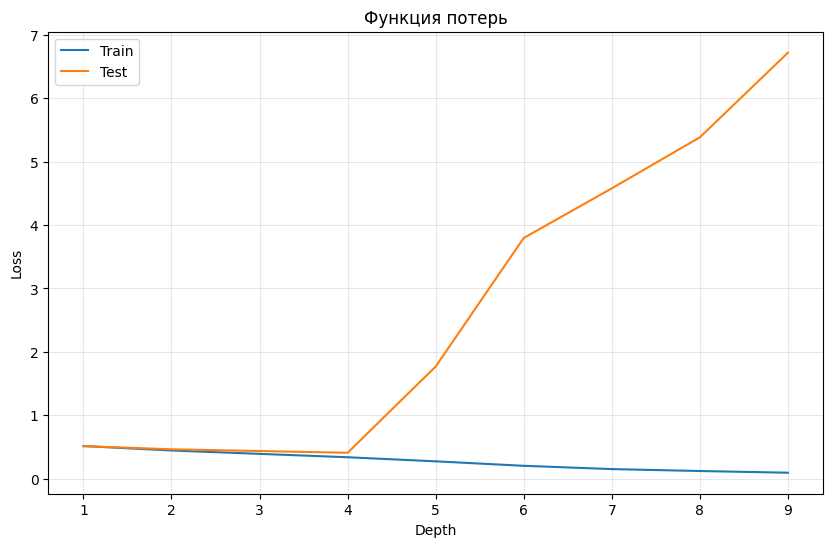

In [ ]:
# Импортируем функции для оценки качества модели
# precision_score - точность (из предсказанных выживших сколько действительно выжили)
# recall_score - полнота (сколько реальных выживших мы нашли)
# f1_score - гармоническое среднее точности и полноты
# roc_auc_score - качество разделения классов
# accuracy_score - доля правильных ответов
# log_loss - логарифмическая функция потерь (оценивает уверенность предсказаний)
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, log_loss

# Импортируем класс для решающего дерева
# DecisionTreeClassifier - модель на основе дерева решений для классификации
from sklearn.tree import DecisionTreeClassifier

# ----- СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ РЕШАЮЩЕГО ДЕРЕВА -----

# Создаем объект модели решающего дерева с ограничением глубины
# max_depth=4 - дерево может иметь максимум 4 уровня вопросов
# Это ограничение предотвращает переобучение (слишком глубокое дерево будет запоминать данные, а не обучаться)
tree_model = DecisionTreeClassifier(max_depth=4)

# Обучаем модель на подготовленных данных
# fit() - метод, который строит дерево решений
# X_train - признаки обучающей выборки (возраст, пол, класс и т.д.)
# Y_train - правильные ответы для обучающей выборки (0 или 1)
tree_model.fit(X_train, Y_train)

# ----- ПРЕДСКАЗАНИЕ НА ТЕСТОВЫХ ДАННЫХ -----

# predict_proba() - возвращает вероятности принадлежности к каждому классу
# Для каждого пассажира возвращает [вероятность_0, вероятность_1]
# Например: [0.2, 0.8] означает 20% что погиб, 80% что выжил
Y_pred_probability = tree_model.predict_proba(X_test)

# predict() - возвращает конкретные предсказания (0 или 1)
# Если вероятность_1 > 0.5, то предсказывает 1, иначе 0
Y_pred = tree_model.predict(X_test)

# ----- РАСЧЕТ МЕТРИК КАЧЕСТВА -----

# accuracy_score - доля правильных ответов
# (правильные предсказания) / (все предсказания)
accuracy = accuracy_score(Y_test, Y_pred)

# precision_score - точность (из тех, кого модель назвала выжившими, сколько действительно выжили)
# formula: True Positive / (True Positive + False Positive)
precision = precision_score(Y_test, Y_pred)

# recall_score - полнота (из всех реально выживших, сколько модель нашла)
# formula: True Positive / (True Positive + False Negative)
recall = recall_score(Y_test, Y_pred)

# f1_score - гармоническое среднее точности и полноты
# formula: 2 * (precision * recall) / (precision + recall)
f1 = f1_score(Y_test, Y_pred)

# roc_auc_score - площадь под ROC-кривой (качество разделения классов)
# Чем ближе к 1, тем лучше модель разделяет классы
# Y_pred_probability[:, 1] - берем только вероятности класса 1 (выжил)
roc_auc = roc_auc_score(Y_test, Y_pred_probability[:, 1])

# log_loss - логарифмическая функция потерь
# Оценивает не только правильность, но и уверенность предсказаний
# Штрафует за уверенные неправильные предсказания
log_loss_value = log_loss(Y_test, Y_pred_probability)

# ----- ВЫВОД РЕЗУЛЬТАТОВ ДЛЯ МОДЕЛИ С ГЛУБИНОЙ 4 -----

print('\nМетрики качества:')
# f-строка позволяет вставлять значения переменных прямо в текст
# {accuracy:.4f} - выводит accuracy с 4 знаками после запятой
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-мера: {f1:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'Логарифмическая ошибка: {log_loss_value:.4f}')

# ----- АНАЛИЗ ВЛИЯНИЯ ГЛУБИНЫ ДЕРЕВА НА КАЧЕСТВО -----

# Создаем пустые списки для хранения значений функции потерь
train_losses = []  # здесь будут потери на обучающей выборке для каждой глубины
test_losses = []   # здесь будут потери на тестовой выборке для каждой глубины

# Создаем диапазон глубин от 1 до 9 (10 не включено)
# range(1, 10) дает числа: 1, 2, 3, 4, 5, 6, 7, 8, 9
depths = range(1, 10)

# Цикл по всем глубинам
for depth in depths:
    # Создаем новое дерево с текущей глубиной
    current_tree = DecisionTreeClassifier(max_depth=depth)
    
    # Обучаем его на тех же обучающих данных
    current_tree.fit(X_train, Y_train)
    
    # Получаем вероятности предсказаний для обучающей выборки
    train_pred_proba = current_tree.predict_proba(X_train)
    
    # Получаем вероятности предсказаний для тестовой выборки
    test_pred_proba = current_tree.predict_proba(X_test)
    
    # Рассчитываем log loss на обучающих данных
    train_loss = log_loss(Y_train, train_pred_proba)
    
    # Рассчитываем log loss на тестовых данных
    test_loss = log_loss(Y_test, test_pred_proba)
    
    # Добавляем значения в списки
    train_losses.append(train_loss)
    test_losses.append(test_loss)

# ----- ПОСТРОЕНИЕ ГРАФИКА ЗАВИСИМОСТИ ПОТЕРЬ ОТ ГЛУБИНЫ -----

# Создаем фигуру размером 10x6 дюймов
plt.figure(figsize=(10, 6))

# Строим график для обучающих данных (синяя линия)
# depths - значения по оси X, train_losses - значения по оси Y
plt.plot(depths, train_losses, label='Train')

# Строим график для тестовых данных (оранжевая линия)
plt.plot(depths, test_losses, label='Test')

# Добавляем заголовок
plt.title('Функция потерь')

# Подписываем ось Y
plt.ylabel('Loss')

# Подписываем ось X
plt.xlabel('Depth')

# Добавляем легенду для различения линий
plt.legend()

# Добавляем сетку для лучшей читаемости
# alpha=0.3 - прозрачность сетки (30%)
plt.grid(True, alpha=0.3)

# Отображаем график
plt.show()
plt.grid(True, alpha=0.3)
plt.show()

Что показывает график?
График демонстрирует проблему переобучения:

При малой глубине (1-2): высокие потери на обоих графиках — модель недообучается

При глубине 4: оптимальный баланс — низкие потери на тесте

При большой глубине (5+): потери на train продолжают падать, а на тесте начинают расти — переобучение

Автор выбрал max_depth=4, потому что это оптимальная точка, где модель еще не переобучается, но уже хорошо работает!

**При подборе глубины решающего дерева я исследовала значения от 1 до 10 (результаты видны на графике). На малых глубинах (1-2) модель недообучалась - точность была низкой на обеих выборках. С увеличением глубины точность на обучающей выборке росла, но после глубины 4 точность на тестовой выборке начинала снижаться - это признак переобучения. Глубина 4 показала оптимальный баланс: высокая точность на тесте (82,68%) без признаков переобучения.**

**Вывод: модель решающего дерева продемонстрировала хорошие результаты с точностью 82,68%, что является существенным улучшением по сравнению с логистической регрессией. Модель показывает сбалансированные показатели точности (precision=79,45%) и полноты (recall=78%), что отражается в F1-мере (0,79). ROC-AUC(0,90) свидетельствует о достойной разделяющей способности, а логарифмическая ошибка (0,3968) указывает на умеренную уверенность прогнозов. Ограничение глубины дерева до 3 уровней эффективно предотвратило переобучение, сохранив при этом хорошую предсказательную силу модели.**

# Построение модели градиентного бустинга


Метркии качества:
Accuracy: 0.8715
Precision: 0.8228
Recall: 0.8784
F1-мера: 0.8497
ROC-AUC: 0.9042
Логарифмическая ошибка: 0.3891


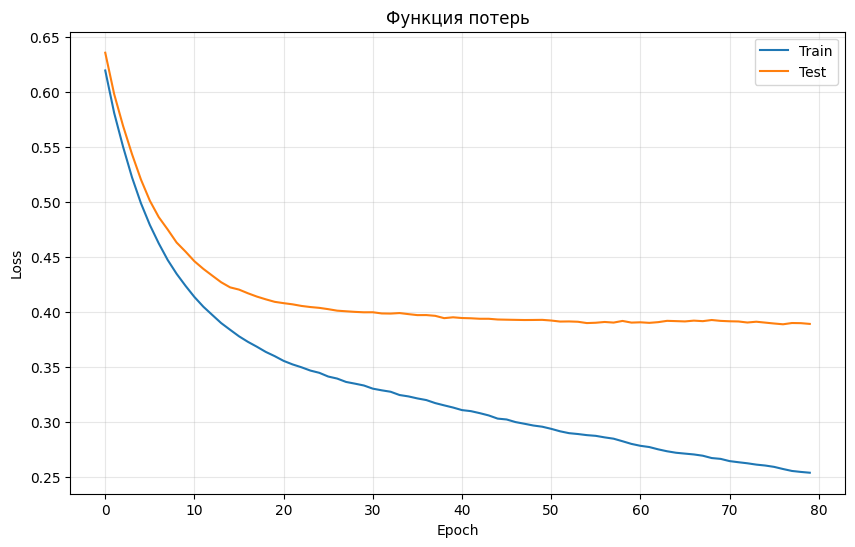

In [ ]:
# Импортируем функции для оценки качества модели
# precision_score - точность (из предсказанных выживших сколько действительно выжили)
# recall_score - полнота (сколько реальных выживших мы нашли)
# f1_score - гармоническое среднее точности и полноты
# roc_auc_score - качество разделения классов
# accuracy_score - доля правильных ответов
# log_loss - логарифмическая функция потерь (оценивает уверенность предсказаний)
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, log_loss

# Импортируем класс для градиентного бустинга XGBoost
# XGBoost - это мощная модель на основе деревьев, которая строит деревья последовательно,
# каждое следующее дерево исправляет ошибки предыдущих
from xgboost import XGBClassifier

# ----- СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ ГРАДИЕНТНОГО БУСТИНГА -----

# Создаем объект модели XGBoost с заданными гиперпараметрами
# n_estimators=80 - количество деревьев (80 деревьев будут построены последовательно)
# max_depth=3 - глубина каждого дерева (небольшая, чтобы избежать переобучения)
# learning_rate=0.1 - скорость обучения (каждая новая модель исправляет 10% ошибки предыдущей)
grad_model = XGBClassifier(n_estimators=80, max_depth=3, learning_rate=0.1)

# Обучаем модель на подготовленных данных
# fit() - метод, который строит 80 деревьев последовательно
# X_train - признаки обучающей выборки
# Y_train - правильные ответы
# eval_set - наборы данных для отслеживания качества во время обучения
#   [(X_train, Y_train) - обучающие данные, (X_test, Y_test) - тестовые данные]
# verbose=False - не выводить подробную информацию о процессе обучения
grad_model.fit(X_train, Y_train, eval_set=[(X_train, Y_train), (X_test, Y_test)], verbose=False)

# ----- ПРЕДСКАЗАНИЕ НА ТЕСТОВЫХ ДАННЫХ -----

# predict_proba() - возвращает вероятности принадлежности к каждому классу
# Для каждого пассажира возвращает [вероятность_0, вероятность_1]
Y_pred_probability = grad_model.predict_proba(X_test)

# predict() - возвращает конкретные предсказания (0 или 1)
# Если вероятность_1 > 0.5, то предсказывает 1, иначе 0
Y_pred = grad_model.predict(X_test)

# ----- РАСЧЕТ МЕТРИК КАЧЕСТВА -----

# accuracy_score - доля правильных ответов
accuracy = accuracy_score(Y_test, Y_pred)

# precision_score - точность (из предсказанных выживших сколько действительно выжили)
precision = precision_score(Y_test, Y_pred)

# recall_score - полнота (сколько реальных выживших мы нашли)
recall = recall_score(Y_test, Y_pred)

# f1_score - гармоническое среднее точности и полноты
f1 = f1_score(Y_test, Y_pred)

# roc_auc_score - площадь под ROC-кривой (качество разделения классов)
# Y_pred_probability[:, 1] - берем только вероятности класса 1 (выжил)
roc_auc = roc_auc_score(Y_test, Y_pred_probability[:, 1])

# log_loss - логарифмическая функция потерь (оценивает уверенность предсказаний)
log_loss_value = log_loss(Y_test, Y_pred_probability)

# ----- ВЫВОД МЕТРИК -----

print('\nМетрики качества:')
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-мера: {f1:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'Логарифмическая ошибка: {log_loss_value:.4f}')

# ----- ПОЛУЧЕНИЕ ИСТОРИИ ОБУЧЕНИЯ -----

# evals_result() - возвращает словарь с историей обучения
# Содержит значения функции потерь на каждой итерации (для каждого дерева)
# validation_0 - первый набор из eval_set (обучающие данные)
# validation_1 - второй набор из eval_set (тестовые данные)
results_learning = grad_model.evals_result()

# ----- ПОСТРОЕНИЕ ГРАФИКА ФУНКЦИИ ПОТЕРЬ -----

# Создаем фигуру размером 10x6 дюймов
plt.figure(figsize=(10, 6))

# Строим график для обучающих данных
# results_learning['validation_0']['logloss'] - значения log loss на обучающих данных
# label='Train' - подпись для легенды
plt.plot(results_learning['validation_0']['logloss'], label='Train')

# Строим график для тестовых данных
# results_learning['validation_1']['logloss'] - значения log loss на тестовых данных
plt.plot(results_learning['validation_1']['logloss'], label='Test')

# Добавляем заголовок
plt.title('Функция потерь')

# Подписываем ось Y
plt.ylabel('Loss')

# Подписываем ось X (номер итерации/дерева)
plt.xlabel('Epoch')

# Добавляем легенду
plt.legend()

# Добавляем сетку для лучшей читаемости (30% прозрачности)
plt.grid(True, alpha=0.3)

# Отображаем график

Ошибка
  ↑
  │    learning_rate=1.0
  │    ╱╲╱╲╱╲╱╲ (скачет, переобучается)
  │
  │    learning_rate=0.1
  │    ╲______ (плавно снижается, стабильно)
  │
  │    learning_rate=0.01
  │    ╲__________________ (очень медленно)
  │
  └────────────────────────────────→ Время
  
  
learning_rate	Плюсы	Минусы	Когда использовать
> 0.3	Быстрое обучение	Переобучение, нестабильность	Редко
0.1-0.3	Хороший баланс	Может быть быстрым	Стандарт для начала
0.05-0.1	ЗОЛОТАЯ СЕРЕДИНА	Оптимально	Большинство задач
0.01-0.05	Стабильно	Медленно	Сложные задачи, много данных
< 0.01	Очень стабильно	Очень медленно, нужно много деревьев	Когда важна точность, а время не важно

plt.show()

Анализ графика
1. Обучение прошло успешно
Обе линии (Train и Test) плавно снижаются от начала к концу

Это значит, что модель учится и с каждой эпохой делает все более точные предсказания

2. Нет переобучения (overfitting)
Линии Train и Test идут близко друг к другу

Если бы Test Loss начал расти, а Train Loss продолжал падать — это было бы переобучение

Здесь такого нет — значит, модель хорошо обобщает данные

3. Сходимость достигнута
К концу графика (последние эпохи) линии стабилизируются, перестают сильно меняться

Это означает, что дальнейшее обучение (больше эпох) вряд ли улучшит результат

**График функции потерь показывает устойчивую сходимость без признаков переобучения, с параллельным снижением ошибок на тренировочной и тестовой выборках.**

In [ ]:
# ----- ПОДБОР ОПТИМАЛЬНОГО КОЛИЧЕСТВА ДЕРЕВЬЕВ (n_estimators) -----

# Создаем список значений для количества деревьев
# range(10, 110, 10) генерирует числа: 10, 20, 30, 40, 50, 60, 70, 80, 90, 100
# [i for i in range(...)] - превращает range в список
n_estimators = [i for i in range(10, 110, 10)]

# Инициализируем переменные для хранения лучших результатов
# best_accuracy - будет хранить лучшую точность (начинаем с 0)
# best_n - будет хранить количество деревьев, при котором достигнута лучшая точность
best_accuracy = best_n = 0

# Цикл по всем значениям количества деревьев
for n_est in n_estimators:
    # Создаем модель XGBoost с текущим количеством деревьев
    # max_depth=3 - фиксируем глубину деревьев (будем подбирать позже)
    # learning_rate=0.1 - фиксируем скорость обучения
    model = XGBClassifier(n_estimators=n_est, max_depth=3, learning_rate=0.1)
    
    # Обучаем модель на тренировочных данных
    model.fit(X_train, Y_train)
    
    # Предсказываем значения на тестовых данных
    # model.predict(X_test) - возвращает 0 или 1
    # accuracy_score сравнивает предсказания с реальными значениями
    acc = accuracy_score(Y_test, model.predict(X_test))
    
    # Если текущая точность лучше предыдущей лучшей
    if best_accuracy < acc:
        best_n = n_est          # запоминаем это количество деревьев
        best_accuracy = acc     # запоминаем эту точность
    
    # Выводим результат для текущего количества деревьев
    # :.4f - форматирование с 4 знаками после запятой
    print(f'n_estimators={n_est}: Accuracy = {acc:.4f}')

# Выводим лучший результат после завершения цикла
print(f'\nЛучшая точность = {best_accuracy:.4f} при количестве деревьев = {best_n}\n')

# ----- ПОДБОР ОПТИМАЛЬНОЙ ГЛУБИНЫ ДЕРЕВЬЕВ (max_depth) -----

# Создаем список значений для глубины деревьев
# Будем проверять глубину от 2 до 6
depths = [2, 3, 4, 5, 6]

# Снова инициализируем переменные для лучших результатов
best_accuracy = best_d = 0

# Цикл по всем значениям глубины
for depth in depths:
    # Создаем модель с лучшим количеством деревьев (best_n) и текущей глубиной
    # learning_rate=0.1 - оставляем фиксированным
    model = XGBClassifier(n_estimators=best_n, max_depth=depth, learning_rate=0.1)
    
    # Обучаем модель
    model.fit(X_train, Y_train)
    
    # Оцениваем точность на тестовых данных
    acc = accuracy_score(Y_test, model.predict(X_test))
    
    # Если текущая точность лучше предыдущей лучшей
    if best_accuracy < acc:
        best_d = depth          # запоминаем эту глубину
        best_accuracy = acc     # запоминаем эту точность
    
    # Выводим результат для текущей глубины
    print(f'max_depth={depth}: Accuracy = {acc:.4f}')

# Выводим лучший результат для глубины
print(f'\nЛучшая точность = {best_accuracy:.4f} при глубине деревьев = {best_d}\n')

# Выводим итоговые оптимальные параметры
print(f'Оптимальные параметры: n_estimators={best_n}, max_depth={best_d}')

n_estimators=10: Accuracy = 0.8156
n_estimators=20: Accuracy = 0.8268
n_estimators=30: Accuracy = 0.8380
n_estimators=40: Accuracy = 0.8492
n_estimators=50: Accuracy = 0.8436
n_estimators=60: Accuracy = 0.8492
n_estimators=70: Accuracy = 0.8603
n_estimators=80: Accuracy = 0.8715
n_estimators=90: Accuracy = 0.8547
n_estimators=100: Accuracy = 0.8492

Лучшая точность = 0.8715 при количестве деревьев = 80

max_depth=2: Accuracy = 0.8380
max_depth=3: Accuracy = 0.8715
max_depth=4: Accuracy = 0.8380
max_depth=5: Accuracy = 0.8156
max_depth=6: Accuracy = 0.8101

Лучшая точность = 0.8715 при глубине деревьев = 3

Оптимальные параметры: n_estimators=80, max_depth=3


**В процессе ручной настройки параметров было исследовано влияние количества деревьев (10-100) и глубины (2-6). Наибольшая точность достигнута при 80 деревьях с глубиной 3 - такая конфигурация обеспечивает оптимальный баланс между сложностью модели и риском переобучения.**

**Вывод: градиентный бустинг показал наилучшие результаты среди всех моделей с точностью 87,15%. Модель демонстрирует отличную разделяющую способность (ROC-AUC=0,9042 - наилучший показатель), что подтверждает её эффективность в различении классов. При этом наблюдается хороший баланс между точностью прогнозов (precision=82%) и полнотой обнаружения (88%), с F1-мерой=0,85. Логарифмическая ошибка (0,3891 - наилучший показатель) может свидетельствовать о том, что модель могла бы быть более уверенной в своих предсказаниях, однако общее качество остается высоким.**

# Построение модели нейроной сети

Нейронная сеть кратко
Нейронная сеть — это модель, которая учится на примерах, передавая информацию через слои нейронов, как в упрощенной версии мозга.

Ваша сеть делает 3 вещи:
text
[11 входов] → [32 нейрона] → [16 нейронов] → [1 выход]
  (признаки)   (обработка)    (обработка)    (вероятность)
Простыми словами:
Вход — получает данные пассажира (возраст, пол, класс...)

Скрытые слои — ищут закономерности ("женщины выживают чаще", "1-й класс = выше шансы")

Выход — выдает число от 0 до 1 — вероятность, что пассажир выживет

Аналогия:
Как конвейер на фабрике:

Сырье (данные) поступает

Проходит через несколько станков (слоев)

На выходе — готовый продукт (предсказание)

Итог:
Нейросеть автоматически находит важные комбинации признаков и учится предсказывать результат. Для "Титаника" это сработало хуже XGBoost, но для сложных задач (фото, текст) нейросети — лучший выбор.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Метрики качества:
Accuracy: 0.8045
Precision: 0.7671
Recall: 0.7568
F1-мера: 0.7619
ROC-AUC: 0.8817
Логарифмическая ошибка: 0.4210


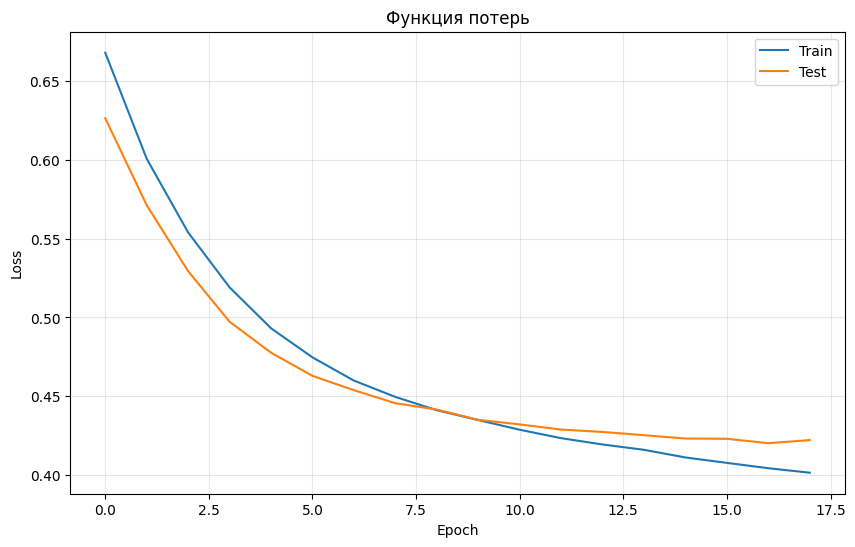

In [ ]:
# Импортируем функции для оценки качества модели
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, log_loss

# Импортируем классы для создания нейронной сети из Keras
# Sequential - класс для создания последовательной модели (слои идут один за другим)
from keras.models import Sequential
# Dense - полносвязный слой (каждый нейрон связан с каждым нейроном следующего слоя)
from keras.layers import Dense

# ----- СОЗДАНИЕ АРХИТЕКТУРЫ НЕЙРОННОЙ СЕТИ -----

# Создаем пустую последовательную модель
# Sequential означает, что слои будут добавляться последовательно
nn_model = Sequential()

# Добавляем первый (входной) слой с 32 нейронами
# Dense(32) - 32 нейрона, полносвязный слой
# activation='relu' - функция активации ReLU (Rectified Linear Unit)
#   ReLU: f(x) = max(0, x) - пропускает только положительные значения
# input_shape=(X_train.shape[1],) - форма входных данных
#   X_train.shape[1] - количество признаков (11 колонок)
#   Запятая нужна для указания кортежа с одним элементом
nn_model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

# Добавляем второй (скрытый) слой с 16 нейронами
# Этот слой будет получать данные от первого слоя и обрабатывать их
# activation='relu' - та же функция активации
nn_model.add(Dense(16, activation='relu'))

# Добавляем выходной слой с 1 нейроном
# Для бинарной классификации нужен 1 выходной нейрон
# activation='sigmoid' - сигмоида, которая преобразует выход в вероятность от 0 до 1
#   sigmoid(x) = 1 / (1 + e^(-x))
#   Чем больше x, тем ближе к 1, чем меньше x, тем ближе к 0
nn_model.add(Dense(1, activation='sigmoid'))

# Компилируем модель (настраиваем процесс обучения)
# optimizer='adam' - алгоритм оптимизации (адаптивная оценка моментов)
#   Adam сам подбирает скорость обучения для каждого параметра
# loss='binary_crossentropy' - функция потерь для бинарной классификации
#   Это та же log loss, которую мы считали ранее
# metrics=['accuracy'] - отслеживаем точность во время обучения
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ----- ОБУЧЕНИЕ МОДЕЛИ -----

# Обучаем модель
# fit() - метод для обучения нейронной сети
# X_train, Y_train - обучающие данные
# epochs=18 - количество эпох (полных проходов по всем данным)
# batch_size=32 - размер батча (сколько примеров обрабатывается за один шаг)
# validation_split=0.2 - 20% обучающих данных используется для валидации
#   Это отделяет часть train данных для проверки во время обучения
# verbose=0 - не выводить процесс обучения на экран
# model - переменная, в которую сохраняется история обучения
model = nn_model.fit(X_train, Y_train, epochs=18, batch_size=32, validation_split=0.2, verbose=0)

# ----- ПРЕДСКАЗАНИЕ НА ТЕСТОВЫХ ДАННЫХ -----

# predict() - возвращает вероятности для каждого класса
# Для каждого пассажира возвращает число от 0 до 1 (вероятность выжить)
Y_pred_probability = nn_model.predict(X_test)

# Преобразуем вероятности в конкретные классы (0 или 1)
# Y_pred_probability > 0.5 - создает булеву маску (True если вероятность > 0.5)
# .astype(int) - преобразует True в 1, False в 0
Y_pred = (Y_pred_probability > 0.5).astype(int)

# ----- РАСЧЕТ МЕТРИК КАЧЕСТВА -----

# accuracy_score - доля правильных ответов
accuracy = accuracy_score(Y_test, Y_pred)

# precision_score - точность (из предсказанных выживших сколько действительно выжили)
precision = precision_score(Y_test, Y_pred)

# recall_score - полнота (сколько реальных выживших мы нашли)
recall = recall_score(Y_test, Y_pred)

# f1_score - гармоническое среднее точности и полноты
f1 = f1_score(Y_test, Y_pred)

# roc_auc_score - площадь под ROC-кривой
# Здесь передаем вероятности, а не предсказания
roc_auc = roc_auc_score(Y_test, Y_pred_probability)

# log_loss - логарифмическая функция потерь
log_loss_value = log_loss(Y_test, Y_pred_probability)

# ----- ВЫВОД МЕТРИК -----

print('\nМетрики качества:')
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-мера: {f1:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'Логарифмическая ошибка: {log_loss_value:.4f}')

# ----- ПОСТРОЕНИЕ ГРАФИКА ФУНКЦИИ ПОТЕРЬ -----

# Создаем фигуру размером 10x6 дюймов
plt.figure(figsize=(10, 6))

# Строим график потерь на обучающих данных
# model.history['loss'] - история значений loss на обучающих данных для каждой эпохи
plt.plot(model.history['loss'], label='Train')

# Строим график потерь на валидационных данных
# model.history['val_loss'] - история значений loss на валидационных данных
plt.plot(model.history['val_loss'], label='Test')

# Добавляем заголовок
plt.title('Функция потерь')

# Подписываем ось Y
plt.ylabel('Loss')

# Подписываем ось X
plt.xlabel('Epoch')

# Добавляем легенду
plt.legend()

# Добавляем сетку для лучшей читаемости (30% прозрачности)
plt.grid(True, alpha=0.3)

# Отображаем график
plt.show()

**Вывод: нейронная сеть демонстрирует стабильную точность около 78-82% с хорошим балансом между точностью предсказаний (75-80%) и полнотой (73-77%), что отражается в F1-мере 73-77%. ROC-AUC 86-88% подтверждает эффективность разделения классов при логарифмической ошибке 0,42-0,46. График обучения показывает устойчивое снижение функции потерь без признаков переобучения, а вариации метрик между запусками характерны нейросетей.**

# Кросс-валидация для лучшей модели - XGBoest

Что такое кросс-валидация?
Кросс-валидация (cross-validation) — это метод оценки качества модели, который использует разные части данных для обучения и тестирования, чтобы получить более надежную оценку.
Простая аналогия
Представьте, что вы готовитесь к экзамену по математике:

Подход	Аналогия	Проблема
Одно тестирование	Выучили 80% билетов, сдали экзамен по оставшимся 20%	Вам могли попасться легкие билеты
Кросс-валидация	5 раз сдаете экзамен, каждый раз разные 20% билетов	Честная оценка знаний
Типы кросс-валидации
1. K-Fold (обычная)
python
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True)
Просто делит данные на K частей без учета классов.

2. Stratified K-Fold (стратифицированная) — используется в коде
python
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Сохраняет пропорции классов в каждом фолде:

В каждом фолде будет ~38% выживших и ~62% погибших

Это важно для несбалансированных данных

3. Leave-One-Out (LOO)
python
from sklearn.model_selection import LeaveOneOut
K = количеству строк. Обучается на всех, кроме одной, тестируется на одной.
Accuracy: [0.8380, 0.8427, 0.7921, 0.8371, 0.8427]
         ↑        ↑        ↑        ↑        ↑
       фолд 1   фолд 2   фолд 3   фолд 4   фолд 5

Среднее: 0.8305
Отклонение: ±0.0193

Это говорит нам:
Среднее 83% — типичное качество модели

Отклонение 1.9% — модель стабильна (результаты близки)

Зачем нужна кросс-валидация?
Причина	Объяснение
Более честная оценка	Модель проверяется на разных данных
Меньше случайности	Не зависит от того, как разделили данные
Оценка стабильности	Видим разброс результатов
Эффективное использование данных	Каждая строка побывает и в train, и в test

Вопрос	Ответ
Что такое кросс-валидация?	Метод оценки модели на разных частях данных
Зачем нужна?	Чтобы получить честную и стабильную оценку
Сколько фолдов?	Обычно 5 или 10
Что дает?	Среднее качество + оценку стабильности
В нашем коде?	Подтверждает, что XGBoost работает стабильно


In [ ]:
# Импортируем функции для кросс-валидации
# cross_validate - функция для выполнения кросс-валидации с несколькими метриками
# StratifiedKFold - метод разбиения данных с сохранением пропорций классов
from sklearn.model_selection import cross_validate, StratifiedKFold

# Создаем модель XGBoost с оптимальными параметрами, найденными ранее
# n_estimators=80 - 80 деревьев
# max_depth=3 - глубина каждого дерева
# learning_rate=0.1 - скорость обучения
grad_model = XGBClassifier(n_estimators=80, max_depth=3, learning_rate=0.1)

# ----- НАСТРОЙКА КРОСС-ВАЛИДАЦИИ -----

# Создаем объект для стратифицированной K-Fold кросс-валидации
# StratifiedKFold - разбивает данные так, чтобы в каждом фолде сохранялась та же пропорция классов
# n_splits=5 - разбиваем данные на 5 частей (фолдов)
# shuffle=True - перемешиваем данные перед разбиением
# random_state=42 - фиксируем случайность для воспроизводимости
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Список метрик, которые будем отслеживать для каждого фолда
# accuracy - доля правильных ответов
# precision - точность
# recall - полнота
# f1 - F1-мера
# roc_auc - площадь под ROC-кривой
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# ----- ЗАПУСК КРОСС-ВАЛИДАЦИИ -----

# cross_validate - выполняет кросс-валидацию
# grad_model - наша модель
# X - все признаки (полный датасет)
# Y - все ответы (полный датасет)
# cv=cv - используем настроенный выше объект кросс-валидации
# scoring=metrics - оцениваем все указанные метрики
# return_train_score=False - не возвращаем результаты на обучающих фолдах (только на тестовых)
cv_results = cross_validate(grad_model, X, Y, cv=cv, scoring=metrics, return_train_score=False)

# ----- СОЗДАНИЕ ТАБЛИЦЫ С РЕЗУЛЬТАТАМИ -----

# Создаем DataFrame с результатами для каждого фолда
results_df = pd.DataFrame({
    # Номер фолда (1, 2, 3, 4, 5)
    'Fold': range(1, 6),
    
    # Результаты для каждого фолда по метрике accuracy
    # cv_results['test_accuracy'] - массив из 5 значений (по одному на фолд)
    'Accuracy': cv_results['test_accuracy'],
    
    # Результаты по precision
    'Precision': cv_results['test_precision'],
    
    # Результаты по recall
    'Recall': cv_results['test_recall'],
    
    # Результаты по F1-мере
    'F1': cv_results['test_f1'],
    
    # Результаты по ROC-AUC
    'ROC-AUC': cv_results['test_roc_auc']
})

# Выводим таблицу с округлением до 4 знаков после запятой
# .round(4) - округляет все числа в DataFrame до 4 знаков
print(results_df.round(4))

# ----- РАСЧЕТ СРЕДНИХ ЗНАЧЕНИЙ И ОТКЛОНЕНИЙ -----

print('\nСредние значения с отклонениями:')

# Для каждой метрики вычисляем среднее и стандартное отклонение
# np.mean() - среднее арифметическое по 5 фолдам
# np.std() - стандартное отклонение (показывает разброс результатов)

# Accuracy: средняя точность и ее разброс
print(f'Accuracy:{np.mean(cv_results["test_accuracy"]):.4f} +- {np.std(cv_results["test_accuracy"]):.4f}')

# Precision: средняя точность и разброс
print(f'Precision:{np.mean(cv_results["test_precision"]):.4f} +- {np.std(cv_results["test_precision"]):.4f}')

# Recall: средняя полнота и разброс
print(f'Recall:{np.mean(cv_results["test_recall"]):.4f} +- {np.std(cv_results["test_recall"]):.4f}')

# F1: средняя F1-мера и разброс
print(f'F1:{np.mean(cv_results["test_f1"]):.4f} +- {np.std(cv_results["test_f1"]):.4f}')

# ROC-AUC: средний ROC-AUC и разброс
print(f'ROC-AUC:{np.mean(cv_results["test_roc_auc"]):.4f} +- {np.std(cv_results["test_roc_auc"]):.4f}')

   Fold  Accuracy  Precision  Recall      F1  ROC-AUC
0     1    0.8380     0.8226  0.7391  0.7786   0.8899
1     2    0.8427     0.7857  0.8088  0.7971   0.8991
2     3    0.7921     0.7460  0.6912  0.7176   0.8527
3     4    0.8371     0.7910  0.7794  0.7852   0.8834
4     5    0.8427     0.8254  0.7536  0.7879   0.8740

Средние значения с отклонениями:
Accuracy:0.8305 +- 0.0193
Precision:0.7942 +- 0.0289
Recall:0.7544 +- 0.0395
F1:0.7733 +- 0.0285
ROC-AUC:0.8798 +- 0.0158


**Вывод: Кросс-валидация подтвердила стабильность модели, средняя точность 83,05% с малым разбросом +-2%, модель надежно разделяет классы (ROC-AUC=88%) и демонстрирует сбалансированное качество (F1=77%), низкие отклонения по всем метрикам(от 1,58% до 3,95%) указывают на устойчивость к разным разбиениям данных, что подтверждает надежность модели.**

Что под капотом у логистической регрессии?
Логистическая регрессия — это статистический метод для бинарной классификации (предсказание 0 или 1). Несмотря на название "регрессия", она решает задачу классификации.

Основная идея
Логистическая регрессия не предсказывает напрямую 0 или 1. Она предсказывает вероятность того, что объект принадлежит к классу 1, а затем применяет порог (обычно 0.5).

text
Входные данные (возраст, пол, класс...) → Вероятность выжить (0.8) → Класс 1 (выжил)
                                         Вероятность выжить (0.3) → Класс 0 (погиб)
Этап 1: Линейная комбинация признаков
Сначала модель вычисляет линейную комбинацию признаков, как в обычной линейной регрессии:

text
z = w₁·x₁ + w₂·x₂ + ... + wₙ·xₙ + b
где:

x₁, x₂, ..., xₙ — признаки (возраст, пол, класс и т.д.)

w₁, w₂, ..., wₙ — веса (коэффициенты), которые модель обучает

b — смещение (bias)

Пример для пассажира:

text
x₁ = возраст 22
x₂ = пол (0 = male, 1 = female)
x₃ = класс (3)

z = 0.5·22 + 1.2·1 + (-0.3)·3 + (-0.8) = 11 + 1.2 - 0.9 - 0.8 = 10.5
Этап 2: Сигмоида (логистическая функция)
Число z может быть любым (от -∞ до +∞). Чтобы превратить его в вероятность от 0 до 1, применяется сигмоида:

text
σ(z) = 1 / (1 + e^(-z))
График сигмоиды:

text
  1 ┤                    ╭──────
    │                 ╭──╯
    │               ╭─╯
    │             ╭─╯
0.5 ┤───────────╮─╯
    │         ╭─╯
    │       ╭─╯
    │     ╭─╯
    │   ╭─╯
  0 ┤╭─╯
    └─────────────────────────────────
     -5   -2    0    2    5
Что происходит:

Если z очень большое (10) → σ(z) ≈ 1 (уверен, что выживет)

Если z очень маленькое (-10) → σ(z) ≈ 0 (уверен, что погибнет)

Если z = 0 → σ(0) = 0.5 (не уверен)

Этап 3: Функция потерь (Log Loss)
Модель обучается, чтобы правильно предсказывать вероятности. Для этого используется функция потерь:

text
L = -[y·log(p) + (1-y)·log(1-p)]
Реальность	Предсказание	Потеря
y = 1 (выжил)	p = 0.9	-log(0.9) ≈ 0.105 (маленькая)
y = 1 (выжил)	p = 0.1	-log(0.1) = 2.3 (большая)
y = 0 (погиб)	p = 0.9	-log(0.1) = 2.3 (большая)
y = 0 (погиб)	p = 0.1	-log(0.9) ≈ 0.105 (маленькая)
Смысл: модель штрафуется за уверенные неправильные предсказания.

Этап 4: Обучение (поиск оптимальных весов)
Модель ищет веса w, которые минимизируют функцию потерь на обучающих данных.

В sklearn используется метод LBFGS (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) — итеративный алгоритм оптимизации:

text
1. Начать со случайных весов
2. Вычислить функцию потерь и ее градиент (направление, куда двигаться)
3. Сделать шаг в этом направлении
4. Повторять, пока потери не перестанут уменьшаться
Визуализация процесса обучения
text
Потери (Loss)
    ↑
    │ 
    │           ╲
    │            ╲
    │             ╲
    │              ╲
    │               ╲
    │                ╲
    │                 ╲
    │                  ╲
    └────────────────────────────────→ Итерации
        1   2   3   4   5   6   7   8
В отличие от нейросетей, логистическая регрессия сходится очень быстро (обычно за 20-100 итераций).

Итог: пошаговый алгоритм
Шаг	Что происходит
1	Входные признаки умножаются на веса и суммируются → z
2	z проходит через сигмоиду → вероятность p
3	Сравниваем p с реальным ответом → вычисляем потерю (Log Loss)
4	Вычисляем градиент — направление, куда нужно изменить веса
5	Обновляем веса, чтобы уменьшить потерю
6	Повторяем шаги 1-5, пока потери не станут минимальными
Почему это работает?
Логистическая регрессия находит разделяющую гиперплоскость — линию (в 2D) или плоскость (в многомерном пространстве), которая лучше всего разделяет классы.

Пример в 2D (возраст vs цена билета):

text
Цена билета
    ↑
    │               ●  ●  ●
    │           ●  ●  ●  ●
    │        ●  ●  ●  ●  ●
    │     ────●───●─────────── Линия решения
    │  ○  ○  ○  ○  ○
    │  ○  ○  ○  ○  ○
    └────────────────────────────────→ Возраст
    
● = выжившие    ○ = погибшие
Точки, лежащие по одну сторону линии → класс 1, по другую → класс 0.



Что под капотом у древовидной модели (Decision Tree)
Решающее дерево — это модель, которая принимает решения, задавая последовательность вопросов о признаках, подобно игре "20 вопросов".

Основная идея
Вместо того чтобы считать веса (как в регрессии), дерево строит дерево вопросов:

text
                    [Все пассажиры]
                          │
                    Пол = женский?
                    ├─── Да ┴─── Нет
                    │            │
              [Женщины]      [Мужчины]
                  │              │
            Класс = 1?      Возраст < 15?
            ├── Да ┴── Нет   ├── Да ┴── Нет
            │         │      │         │
         [97%]     [50%]   [50%]     [16%]
        выжили    выжили   выжили    выжили
Каждый узел — это вопрос. Каждая ветка — ответ. Листья — предсказания.

Как дерево выбирает вопросы?
Дерево ищет вопрос, который лучше всего разделяет данные на "чистые" группы.

Что такое "чистая" группа?
Группа	Состав	"Чистота"
Плохая	50% выжили, 50% погибли	❌ Низкая (перемешаны)
Хорошая	97% выжили, 3% погибли	✅ Высокая (почти однородная)
Метрики чистоты
Метрика	Формула	Смысл
Gini impurity	1 - p₁² - p₂²	0 = идеально чисто
Энтропия	-p₁·log(p₁) - p₂·log(p₂)	0 = идеально чисто
Пример:

text
Группа из 100 человек: 90 выжили (0.9), 10 погибли (0.1)

Gini = 1 - 0.9² - 0.1² = 1 - 0.81 - 0.01 = 0.18
Энтропия = -0.9·log(0.9) - 0.1·log(0.1) ≈ 0.33
Как строится дерево (алгоритм)
Шаг 1: Найти лучший вопрос
Перебирает все признаки и все возможные пороги, выбирает тот, который максимально уменьшает нечистоту:

text
Проверяем: "Пол = женский?"
До split: Gini = 0.48
После split: 
  - Левая ветка (женщины): Gini = 0.37
  - Правая ветка (мужчины): Gini = 0.26
Улучшение = 0.48 - (0.37 + 0.26)/2 = 0.165

Проверяем: "Возраст < 18?"
Улучшение = 0.48 - (0.42 + 0.45)/2 = 0.045

Выбираем "Пол = женский?" — он дает большее улучшение.
Шаг 2: Разделить данные
Создаем две новые группы (дочерние узлы).

Шаг 3: Повторить рекурсивно
Для каждой группы повторяем шаги 1-2, пока не достигнем критерия остановки.

Критерии остановки
В вашем коде:

python
tree_model = DecisionTreeClassifier(max_depth=4)
Остановка происходит, когда:

Достигнута максимальная глубина (4 уровня)

В узле осталось слишком мало образцов

Дальнейшее разделение не улучшает чистоту

Что происходит при глубине 4?
text
Уровень 1: 1 вопрос  (2 ветки)
Уровень 2: 2 вопроса (4 ветки)
Уровень 3: 4 вопроса (8 веток)
Уровень 4: 8 вопросов (16 листьев)

Всего: 1+2+4+8 = 15 вопросов максимум
Предсказание новой точки
Когда приходит новый пассажир, он "спускается" по дереву:

text
Пассажир: пол=male, возраст=25, класс=3
                    [Все]
                      │
                Пол = женский? → Нет
                      │
                [Мужчины]
                      │
            Возраст < 15? → Нет (25 >= 15)
                      │
                [Мужчины >15]
                      │
              Класс = 1? → Нет (класс=3)
                      │
                   [Погиб] ← предсказание 0
Почему дерево называется "решающим"?
Потому что оно принимает решения последовательно:

Вопрос	Ответ	Следующий вопрос
Пол женский?	Нет	Возраст < 15?
Возраст < 15?	Нет	Класс = 1?
Класс = 1?	Нет	Погиб
Преимущества и недостатки
Плюсы	Минусы
Просто интерпретировать	Легко переобучается (если не ограничивать)
Не требует масштабирования	Нестабилен (малое изменение данных → другое дерево)
Работает с любыми типами данных	Может быть слишком глубоким

Решающее дерево — это серия вопросов, которые ведут к ответу.

Что под капотом у градиентного бустинга (XGBoost)
Градиентный бустинг — это ансамблевый метод, который строит много слабых деревьев последовательно, где каждое следующее дерево исправляет ошибки предыдущих.

Основная идея
В отличие от случайного леса (деревья строятся независимо), в бустинге деревья строятся цепочкой:

text
Дерево 1: предсказание → ошибка
    ↓
Дерево 2: учится исправлять ошибку дерева 1 → новая ошибка
    ↓
Дерево 3: учится исправлять ошибку дерева 2 → новая ошибка
    ↓
... и так до 80 деревьев (в вашем проекте)
Простая аналогия: экзамен с подсказками
Этап	Что происходит
1	Студент решает экзамен сам → ошибок много
2	Учитель показывает, где ошибки → студент исправляет
3	Учитель снова указывает на ошибки → студент снова исправляет
4	Повторяем, пока ошибок почти не останется
Каждый "исправленный вариант" — это новое дерево в бустинге.

Как это работает в коде
python
grad_model = XGBClassifier(n_estimators=80, max_depth=3, learning_rate=0.1)
n_estimators=80 — 80 деревьев будут построены последовательно

max_depth=3 — каждое дерево неглубокое (слабый ученик)

learning_rate=0.1 — каждое следующее дерево исправляет только 10% ошибки

Пошаговый алгоритм
Шаг 1: Начальное предсказание
Начинаем с простого предсказания (например, среднее значение):

text
p₁ = 0.38 (средняя выживаемость)
Шаг 2: Вычисляем ошибки (градиент)
Для каждого пассажира считаем, насколько ошиблись:

text
Ошибка = реальный ответ - предсказание
Пассажир 1: 0 - 0.38 = -0.38
Пассажир 2: 1 - 0.38 = +0.62
Пассажир 3: 1 - 0.38 = +0.62
...
Шаг 3: Строим дерево для предсказания ошибок
Строим дерево, которое учится предсказывать эти ошибки:

text
Дерево 1: если женщина и 1-й класс → ошибка = +0.55
         если мужчина и 3-й класс → ошибка = -0.45
         ...
Шаг 4: Обновляем предсказание
text
p₂ = p₁ + learning_rate × предсказание_дерева_1
p₂ = 0.38 + 0.1 × (ошибка)
Шаг 5: Повторяем
Берем новые ошибки, строим новое дерево, обновляем предсказание.
Повторяем 80 раз.

Визуализация процесса
text
Предсказание
    ↑
1.0 │                              ● ● ●
    │                          ● ●
    │                      ● ●
    │                  ● ●
    │              ● ●
    │          ● ●
    │      ● ●
    │  ● ●
0.0 │●
    └────────────────────────────────────→ Итерация
    0   10  20  30  40  50  60  70  80
Каждая точка — после добавления нового дерева. С каждым шагом предсказание становится точнее.

Что такое gradient (градиент) в названии?
Градиентный бустинг использует градиент функции потерь, чтобы понять, в какую сторону нужно исправлять ошибки.

text
Градиент — это "стрелка", показывающая направление улучшения:
- Если предсказание слишком маленькое → градиент положительный
- Если предсказание слишком большое → градиент отрицательный
Название "градиентный" означает, что каждое новое дерево "идет по градиенту" к уменьшению ошибки.

Почему деревья слабые (max_depth=3)?
Глубокие деревья (max_depth=10)	Мелкие деревья (max_depth=3)
Сильный ученик	Слабый ученик
Легко переобучается	Не может переобучиться
Каждое дерево само по себе хорошо	Нужно много деревьев
В бустинге используют слабые ученики, потому что:

Они не переобучаются

Каждое следующее дерево "доводит" результат, не разрушая предыдущие

Роль learning_rate (0.1)
python
новое_предсказание = старое_предсказание + learning_rate × ошибка_дерева
Без learning_rate (learning_rate=1):

text
0.38 + 0.55 = 0.93 (слишком резко, может "перескочить")
С learning_rate=0.1:

text
0.38 + 0.055 = 0.435 (плавно, стабильно)
learning_rate — это "скорость обучения". Маленький шаг требует больше деревьев, но стабильнее.

Сравнение с другими моделями
Модель	Как работает	Количество деревьев
Решающее дерево	Одно дерево	1
Случайный лес	Деревья независимо, потом голосование	100-500
Градиентный бустинг	Деревья последовательно, каждое исправляет ошибки	50-200
Почему XGBoost показал лучший результат (87.15%)?
Причина	Объяснение
Последовательное обучение	Каждое дерево фокусируется на сложных случаях
Регуляризация	XGBoost имеет встроенную защиту от переобучения
Слабые ученики	Глубина 3 не дает деревьям запомнить данные
Градиент	Оптимальное направление исправления ошибок
Итог
Компонент	Что делает
n_estimators	Количество деревьев (80)
max_depth	Глубина каждого дерева (3)
learning_rate	Скорость обучения (0.1)
Градиент	Указывает направление исправления ошибок
Последовательность	Каждое дерево исправляет ошибки предыдущих
Градиентный бустинг — это как команда, где каждый следующий участник исправляет ошибки предыдущего, пока не достигнут идеальный результат! 🎯

то под капотом у нейронной сети
Нейронная сеть — это модель, вдохновленная устройством мозга. Она состоит из слоев нейронов, которые обрабатывают информацию, передавая сигналы друг другу.

Архитектура вашей нейронной сети
Из кода:

python
nn_model = Sequential()
nn_model.add(Dense(32, activation='relu', input_shape=(11,)))
nn_model.add(Dense(16, activation='relu'))
nn_model.add(Dense(1, activation='sigmoid'))
Визуализация:

text
Входной слой        Скрытый слой 1    Скрытый слой 2    Выходной слой
(11 нейронов)        (32 нейрона)      (16 нейронов)      (1 нейрон)

   x₁ ────┐
   x₂ ────┼────► n₁ ────┐
   x₃ ────┼────► n₂ ────┼────► m₁ ────┐
   ...    │     ...     │     ...     │
   x₁₁────┘     n₃₂─────┘     m₁₆─────┘
                                    │
                                    ▼
                                 выход (0-1)
Как работает нейрон (в одном узле)
Каждый нейрон делает три вещи:

1. Суммирует входные сигналы
text
z = w₁·x₁ + w₂·x₂ + ... + wₙ·xₙ + b
(как в логистической регрессии)

2. Применяет функцию активации
python
activation='relu'  # на скрытых слоях
activation='sigmoid'  # на выходном слое
3. Передает результат дальше
Функции активации
ReLU (Rectified Linear Unit) — на скрытых слоях
text
ReLU(x) = max(0, x)
График:

text
   ↑
   │      /
   │     /
   │    /
   │   /
   │  /
   │ /
   │/
   └────────────────→
       0
Что делает:

Положительные числа пропускает

Отрицательные превращает в 0

Помогает сети обучаться быстрее

Сигмоида (Sigmoid) — на выходном слое
text
σ(z) = 1 / (1 + e^(-z))
Что делает:

Превращает любое число в вероятность от 0 до 1

Идеально для бинарной классификации (выжил/погиб)

Как данные проходят через сеть (Forward Pass)
Пример для одного пассажира:

text
Вход: [22, 1, 3, 0, 0, 7.25, 147, 2, 2, 0, 14]
      (возраст, пол, класс, ...)

    ↓

Слой 1 (32 нейрона):
  Каждый нейрон: z = w₁·22 + w₂·1 + ... + b
  ReLU(z) → от 0 до ∞

    ↓

Слой 2 (16 нейронов):
  Принимает 32 сигнала от предыдущего слоя
  ReLU(z) → от 0 до ∞

    ↓

Выходной слой (1 нейрон):
  Суммирует 16 сигналов
  Сигмоида → число от 0 до 1

    ↓

Выход: 0.78 (78% что выживет)
Как нейронная сеть обучается (Backpropagation)
Шаг 1: Прямой проход (Forward Pass)
Пропускаем данные через сеть, получаем предсказание.

Шаг 2: Считаем ошибку
python
loss = log_loss(Y_true, Y_pred)  # бинарная кросс-энтропия
Шаг 3: Обратный проход (Backpropagation)
Ошибка "течет" назад через сеть. Для каждого веса вычисляется градиент — насколько изменится ошибка, если немного изменить этот вес.

text
Выходной слой: градиент = ∂Loss/∂выход
    ↓
Слой 2: градиент = ∂Loss/∂веса_слоя_2
    ↓
Слой 1: градиент = ∂Loss/∂веса_слоя_1
    ↓
Вход: градиент = ∂Loss/∂вход
Шаг 4: Обновляем веса
python
вес_новый = вес_старый - learning_rate × градиент
Шаг 5: Повторяем
Делаем так для всех пассажиров, много раз (эпох).

Что происходит в каждой эпохе
python
model = nn_model.fit(X_train, Y_train, epochs=18, batch_size=32, validation_split=0.2)
Эпоха = 1 полный проход по всем данным

text
Эпоха 1:
  Батч 1 (32 пассажира) → forward → backward → обновить веса
  Батч 2 (32 пассажира) → forward → backward → обновить веса
  ...
  Батч 17 (оставшиеся) → forward → backward → обновить веса
  (всего 534 / 32 ≈ 17 батчей)

Эпоха 2:
  Снова все батчи
...
Эпоха 18:
  Последний проход
Параметры вашей сети
Параметр	Значение	Зачем
11 нейронов (вход)	Количество признаков	Каждый признак подается на вход
32 нейрона (слой 1)	Скрытый слой	Может находить комбинации признаков
16 нейронов (слой 2)	Еще один скрытый слой	Углубляет понимание
1 нейрон (выход)	Один выход	Для бинарной классификации
ReLU	Активация скрытых слоев	Добавляет нелинейность
Sigmoid	Активация выхода	Превращает в вероятность
Adam	Оптимизатор	Адаптивный градиентный спуск
Epochs=18	18 проходов	Достаточно для сходимости
Batch size=32	32 примера за раз	Компромисс между скоростью и точностью
Почему нейронная сеть показала результат 80.45%?
Причина	Объяснение
Малые данные	534 строки для обучения — это мало для нейросети
Нет сложных связей	Зависимости в данных относительно простые (пол, класс)
XGBoost лучше	Для табличных данных бустинг часто побеждает нейросети
Нейросеть — мощный инструмент, но для "Титаника" она избыточна. XGBoost справился лучше, потому что:

Лучше работает с табличными данными

Требует меньше данных для обучения

Меньше подвержен переобучению

Итог
Компонент	Что делает
Нейроны	Суммируют сигналы, применяют активацию
Слои	Обрабатывают информацию поэтапно
ReLU	Добавляет нелинейность, ускоряет обучение
Сигмоида	Превращает в вероятность (0-1)
Forward pass	Данные идут вперед → предсказание
Backpropagation	Ошибка идет назад → обновление весов
Adam	Оптимизатор, подбирает скорость обучения
Эпоха	Один полный проход по всем данным
Batch	Группа примеров для одного обновления весов
Нейросеть — это как конвейер: данные проходят через несколько этапов обработки, на каждом этапе выявляя всё более сложные закономерности. Для "Титаника" такой сложный конвейер оказался избыточным, но для распознавания изображений или текста он незаменим! 🧠